# Nepal Election 2082 Vote Pattern Analysis

This notebook upgrades the existing vote-type comparison into a publication-quality analysis using only the currently attached files:

- `nepal_election_2082_results_ec.csv`
- `proportional_votes.csv`
- `Winners_Nepal_election_2082.xlsx`

The analysis focuses on three connected views of the same election:

1. FPTP constituency candidate votes
2. Proportional party-list votes
3. A transparent 275-seat parliament outlook built only from the available files

**Scope guardrails**

- No external data sources are used.
- No previous-election comparisons are introduced.
- Party alignment is kept explicit and reproducible.
- Where the files do not encode the full legal seat-allocation method, the notebook uses a clearly labeled approximation.

In [127]:
from pathlib import Path
import os
import io
import math
import re
import textwrap
import unicodedata
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.text
import matplotlib.colors as mcolors
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import FuncFormatter
from IPython.display import Markdown, display, Image as DisplayImage
from PIL import Image
import base64
import matplotlib

try:
    os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
    from PyQt5.QtCore import Qt
    from PyQt5.QtGui import QColor, QFont, QFontDatabase, QFontMetrics, QGuiApplication, QImage, QPainter
    HAS_QT_TEXT = True
except ImportError:
    Qt = None
    QColor = None
    QFont = None
    QFontDatabase = None
    QFontMetrics = None
    QGuiApplication = None
    QImage = None
    QPainter = None
    HAS_QT_TEXT = False

try:
    import AppKit
    import Quartz
    HAS_CORETEXT = True
except ImportError:
    AppKit = None
    Quartz = None
    HAS_CORETEXT = False

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.facecolor"] = "#fffdf7"
plt.rcParams["figure.facecolor"] = "#f6f1e8"
plt.rcParams["savefig.facecolor"] = "#f6f1e8"

PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "Codes" else Path.cwd().resolve()
NOTEBOOK_PATH = PROJECT_DIR / "Codes" / "vote_type_comparison.ipynb"
OUTPUT_DIR = PROJECT_DIR / "Images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def find_file(filename: str) -> Path:
    matches = list(PROJECT_DIR.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find {filename!r} under {PROJECT_DIR}")
    return matches[0]

RESULTS_PATH = find_file("nepal_election_2082_results_ec.csv")
PR_PATH = find_file("proportional_votes.csv")
WINNERS_PATH = find_file("Winners_Nepal_election_2082.xlsx")

candidate_df = pd.read_csv(RESULTS_PATH)
proportional_df = pd.read_csv(PR_PATH)
winners_xlsx = pd.read_excel(WINNERS_PATH)

DEVANAGARI_FONT_CANDIDATES = [
    "Noto Sans Devanagari",
    "Noto Serif Devanagari",
    "Mangal",
    "Kohinoor Devanagari",
    "Devanagari Sangam MN",
    "ITF Devanagari",
    "Devanagari MT",
    "Shree Devanagari 714",
    "Mukta",
]
DEVANAGARI_SAMPLE_TEXT = "राष्ट्रिय परिवर्तन पार्टी"

def _font_search_dirs():
    return [
        PROJECT_DIR / "fonts",
        PROJECT_DIR / "Fonts",
        PROJECT_DIR / "assets" / "fonts",
        Path.home() / "Library" / "Fonts",
        Path("/Library/Fonts"),
        Path("/System/Library/Fonts"),
    ]

def configure_devanagari_font():
    available_fonts = {font.name: Path(font.fname) for font in fm.fontManager.ttflist}
    for family in DEVANAGARI_FONT_CANDIDATES:
        if family in available_fonts:
            return family, available_fonts[family]

    font_file_candidates = []
    for font_dir in _font_search_dirs():
        if not font_dir.exists():
            continue
        for pattern in ("*.ttf", "*.otf", "*.ttc"):
            font_file_candidates.extend(sorted(font_dir.rglob(pattern)))

    for font_path in font_file_candidates:
        lowered_name = font_path.name.lower()
        if not any(token in lowered_name for token in ("devanagari", "mangal", "noto", "mukta")):
            continue
        try:
            fm.fontManager.addfont(str(font_path))
            family = fm.FontProperties(fname=str(font_path)).get_name()
        except Exception:
            continue
        if family:
            return family, font_path

    raise RuntimeError(
        "No Devanagari-capable font was found. Install Noto Sans Devanagari, Noto Serif Devanagari, Mangal, or place a .ttf/.otf in a local fonts directory."
    )

selected_font, selected_font_path = configure_devanagari_font()
_QT_APP = None
if HAS_QT_TEXT:
    _QT_APP = QGuiApplication.instance() or QGuiApplication([])
    if selected_font_path:
        QFontDatabase.addApplicationFont(str(selected_font_path))
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = [selected_font, *DEVANAGARI_FONT_CANDIDATES, "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

# Qt/CoreText rendering is used for export so saved files keep correct ligatures.
_DEVANAGARI_RE = re.compile(r"[\u0900-\u097F]")
_CT_FONT_NAME = selected_font

def _render_dev_text(text, font_size=13.0, color=(0.1, 0.1, 0.1, 1.0)):
    """Render a Devanagari string with a shaping-capable text engine."""
    if HAS_QT_TEXT:
        font = QFont(selected_font)
        font.setPointSizeF(max(1.0, font_size * 1.55))
        metrics = QFontMetrics(font)
        rect = metrics.boundingRect(text)
        pad = max(8, int(round(font_size * 0.8)))
        image = QImage(max(1, rect.width() + pad * 2), max(1, rect.height() + pad * 2), QImage.Format_ARGB32)
        image.fill(Qt.transparent)
        painter = QPainter(image)
        painter.setRenderHint(QPainter.Antialiasing)
        painter.setRenderHint(QPainter.TextAntialiasing)
        painter.setRenderHint(QPainter.SmoothPixmapTransform)
        painter.setFont(font)
        r, g, b = color[:3]
        a = color[3] if len(color) > 3 else 1.0
        painter.setPen(QColor.fromRgbF(r, g, b, a))
        painter.drawText(pad, pad + metrics.ascent(), text)
        painter.end()
        image = image.convertToFormat(QImage.Format_RGBA8888)
        ptr = image.bits()
        ptr.setsize(image.byteCount())
        arr = np.frombuffer(ptr, dtype=np.uint8).reshape(image.height(), image.width(), 4).copy()
        return Image.fromarray(arr, "RGBA")

    if HAS_CORETEXT:
        font = AppKit.NSFont.fontWithName_size_(_CT_FONT_NAME, font_size * 2)
        if font is None:
            fallback_fonts = [name for name in DEVANAGARI_FONT_CANDIDATES if name != _CT_FONT_NAME]
            for fallback_name in fallback_fonts:
                font = AppKit.NSFont.fontWithName_size_(fallback_name, font_size * 2)
                if font is not None:
                    break
        if font is None:
            font = AppKit.NSFont.systemFontOfSize_(font_size * 2)
        r, g, b = color[:3]
        a = color[3] if len(color) > 3 else 1.0
        ns_color = AppKit.NSColor.colorWithSRGBRed_green_blue_alpha_(r, g, b, a)
        attrs = {
            AppKit.NSFontAttributeName: font,
            AppKit.NSForegroundColorAttributeName: ns_color,
        }
        attr_str = AppKit.NSAttributedString.alloc().initWithString_attributes_(text, attrs)
        size = attr_str.size()
        pad = 8
        w, h = int(size.width) + pad * 2, int(size.height) + pad * 2
        cs = Quartz.CGColorSpaceCreateDeviceRGB()
        ctx = Quartz.CGBitmapContextCreate(None, w, h, 8, w * 4, cs, Quartz.kCGImageAlphaPremultipliedLast)
        Quartz.CGContextClearRect(ctx, Quartz.CGRectMake(0, 0, w, h))
        ns_ctx = AppKit.NSGraphicsContext.graphicsContextWithCGContext_flipped_(ctx, False)
        AppKit.NSGraphicsContext.setCurrentContext_(ns_ctx)
        attr_str.drawAtPoint_((pad, pad))
        AppKit.NSGraphicsContext.setCurrentContext_(None)
        img_ref = Quartz.CGBitmapContextCreateImage(ctx)
        provider = Quartz.CGImageGetDataProvider(img_ref)
        raw = bytes(Quartz.CGDataProviderCopyData(provider))
        arr = np.frombuffer(raw, dtype=np.uint8).reshape(h, w, 4).copy()
        return Image.fromarray(arr, "RGBA")

    raise RuntimeError("No shaping-capable renderer is available. Install PyQt5 or pyobjc.")

def _get_all_texts(fig):
    """Return every Text artist in the figure."""
    texts = list(fig.texts)
    for ax in fig.get_axes():
        texts += ax.get_xticklabels() + ax.get_yticklabels()
        texts += [ax.title, ax.xaxis.label, ax.yaxis.label]
        legend = ax.get_legend()
        if legend:
            texts += legend.get_texts()
        for child in ax.get_children():
            if isinstance(child, matplotlib.text.Text) and child not in texts:
                texts.append(child)
    return texts

def _save_rendered_figure(image, path, export_dpi=240):
    suffix = path.suffix.lower()
    if suffix == ".svg":
        buf = io.BytesIO()
        image.save(buf, format="PNG", dpi=(export_dpi, export_dpi))
        encoded = base64.b64encode(buf.getvalue()).decode("ascii")
        width, height = image.size
        svg = (
            f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">' 
            f'<image width="{width}" height="{height}" href="data:image/png;base64,{encoded}"/>' 
            "</svg>"
        )
        path.write_text(svg, encoding="utf-8")
        return
    if suffix == ".pdf":
        image.convert("RGB").save(path, "PDF", resolution=export_dpi)
        return
    image.save(path, dpi=(export_dpi, export_dpi))

def fix_devanagari_export(fig, path, export_dpi=240):
    """
    Save *fig* to *path* with all Devanagari text replaced by CoreText renders.

    Workflow
    --------
    1. Render the full matplotlib canvas to a PIL image.
    2. For every visible text element that contains Devanagari:
       a. Erase the area with the local background colour.
       b. Paste a CoreText-rendered image centred on the same spot.
    3. Crop to the tight bounding box (+ default 0.1-inch padding) and save.
    """
    bg_color    = fig.get_facecolor()
    fig.canvas.draw()
    renderer    = fig.canvas.get_renderer()
    canvas_dpi  = renderer.dpi
    fig_h_in    = fig.get_figheight()
    canvas_h_px = fig_h_in * canvas_dpi   # total canvas height in px (y=0 at bottom)
    scale       = export_dpi / canvas_dpi  # canvas px → export px

    # Collect Devanagari text elements
    dev_infos = []
    for t in _get_all_texts(fig):
        txt = t.get_text() or ""
        if not (t.get_visible() and _DEVANAGARI_RE.search(txt)):
            continue
        try:
            bb = t.get_window_extent(renderer=renderer)
        except Exception:
            continue
        if bb.width <= 0 or bb.height <= 0:
            continue
        dev_infos.append({
            "text":     txt,
            "bb":       bb,
            "fontsize": t.get_fontsize(),
            "color":    mcolors.to_rgba(t.get_color()),
            "rotation": t.get_rotation(),
        })

    # Save full canvas (no tight-bbox crop) so coordinates are unambiguous
    buf = io.BytesIO()
    fig.savefig(buf, dpi=export_dpi, facecolor=bg_color, format="png")
    buf.seek(0)
    full_img = Image.open(buf).convert("RGBA")
    full_w, full_h = full_img.size

    for info in dev_infos:
        bb       = info["bb"]
        rotation = info["rotation"]
        color    = info["color"]
        text     = info["text"]
        fontsize = info["fontsize"]

        # Canvas px → full PIL px  (y-flip: PIL y=0 at top)
        x0_pil = bb.x0 * scale
        y0_pil = (canvas_h_px - bb.y1) * scale   # top of text bbox in PIL
        x1_pil = bb.x1 * scale
        y1_pil = (canvas_h_px - bb.y0) * scale   # bottom of text bbox in PIL

        px0 = int(x0_pil);  py0 = int(y0_pil)
        pw  = max(1, int(x1_pil - x0_pil))
        ph  = max(1, int(y1_pil - y0_pil))

        px0 = max(0, min(px0, full_w - 1))
        py0 = max(0, min(py0, full_h - 1))
        pw  = min(pw + 4, full_w - px0)
        ph  = min(ph + 4, full_h - py0)
        if pw < 2 or ph < 2:
            continue

        # Sample background colour from just outside the text area
        sx = max(0, px0 - 6);  sy = max(0, py0 + ph // 2)
        try:
            bg_px = full_img.getpixel((sx, sy))[:3]
        except Exception:
            bg_px = tuple(int(c * 255) for c in bg_color[:3])

        # Erase the old (badly-shaped) text with a generous margin
        ep  = max(6, ph // 4)
        ex0 = max(0, px0 - ep);  ey0 = max(0, py0 - ep)
        ew  = min(pw + ep * 2, full_w - ex0)
        eh  = min(ph + ep * 2, full_h - ey0)
        full_img.paste(Image.new("RGBA", (ew, eh), (*bg_px, 255)), (ex0, ey0))

        # Render with CoreText (internally 2× oversampled)
        dev_img = _render_dev_text(text, font_size=fontsize * scale, color=color)

        if abs(rotation) > 1:
            dev_img = dev_img.rotate(-rotation, expand=True, resample=Image.BICUBIC)

        # Scale the CoreText render to fit the bounding box
        dw, dh = dev_img.size
        if dw <= 0 or dh <= 0:
            continue
        ratio = min(pw / dw, (ph + ep) / dh)
        nw = max(1, int(dw * ratio))
        nh = max(1, int(dh * ratio))
        dev_img = dev_img.resize((nw, nh), Image.LANCZOS)

        # Centre-paste
        paste_x = max(0, min(px0 + (pw - nw) // 2, full_w - nw))
        paste_y = max(0, min(py0 + (ph - nh) // 2, full_h - nh))
        full_img.paste(dev_img, (paste_x, paste_y), dev_img)

    # Crop to tight bounding box (replicating bbox_inches="tight", pad_inches=0.1)
    tight_bbox = fig.get_tightbbox(renderer)   # in figure inches
    pad_in = 0.1
    cx0 = max(0, int((tight_bbox.x0 - pad_in) * export_dpi))
    cy0 = max(0, int((fig_h_in - tight_bbox.y1 - pad_in) * export_dpi))
    cx1 = min(full_w, int((tight_bbox.x1 + pad_in) * export_dpi))
    cy1 = min(full_h, int((fig_h_in - tight_bbox.y0 + pad_in) * export_dpi))
    rendered = full_img.crop((cx0, cy0, cx1, cy1))
    _save_rendered_figure(rendered, path, export_dpi=export_dpi)

print(f"Candidate rows loaded: {candidate_df.shape[0]:,}")
print(f"Proportional rows loaded: {proportional_df.shape[0]:,}")
print(f"Winners workbook rows loaded: {winners_xlsx.shape[0]:,}")
print(f"Chart font in use: {selected_font}")
print(f"Font file used: {selected_font_path}")
print(f"Shaping check sample: {DEVANAGARI_SAMPLE_TEXT}")
print(f"Figures export to: {OUTPUT_DIR.relative_to(PROJECT_DIR)}")

Candidate rows loaded: 3,406
Proportional rows loaded: 57
Winners workbook rows loaded: 0
Chart font in use: Kohinoor Devanagari
Font file used: /System/Library/Fonts/Kohinoor.ttc
Shaping check sample: राष्ट्रिय परिवर्तन पार्टी
Figures export to: Images


## Data Loading

The constituency file provides candidate-level FPTP results for 165 House of Representatives constituencies. The proportional file provides party-list totals and ranking. The attached winners workbook is present, but in the current project copy it contains no usable rows for seat extraction, so FPTP winners are computed directly from the official winner flags in the constituency results CSV.

In [128]:
display(candidate_df.head(3))
display(proportional_df.head(3))
display(pd.DataFrame({
    "file": [
        RESULTS_PATH.name,
        PR_PATH.name,
        WINNERS_PATH.name,
    ],
    "rows": [
        candidate_df.shape[0],
        proportional_df.shape[0],
        winners_xlsx.shape[0],
    ],
    "columns": [
        candidate_df.shape[1],
        proportional_df.shape[1],
        winners_xlsx.shape[1],
    ],
    "notes": [
        "Candidate-level FPTP constituency results",
        "Party-level proportional vote totals",
        "Workbook attached but empty in this project snapshot",
    ],
}))

,election_id,election_type,state_id,state_name,district_id,district_name_en,district_name_np,area_id,area_name_en,area_name_np,...,candidate_name_en,candidate_name_np,candidate_slug,candidate_image_url,party_id,party_name_np,votes,winner,leading,is_elected
0,2082,HOR,1,Koshi Province,1,Taplejung,ताप्लेजुङ,1,Area 1,क्षेत्र नं. १,...,Kshitij Thebe,क्षितिज थेबे,kshitij-thebe-a1,https://file-r2.hamropatro.com/election-images...,105,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी ले...,13962,True,False,False
1,2082,HOR,1,Koshi Province,1,Taplejung,ताप्लेजुङ,1,Area 1,क्षेत्र नं. १,...,Gajendra Prasad Tumyang Limbu,गजेन्द्र प्रसाद तुम्याङ लिम्बु,gajendra-prasad-tumyang-limbu-a1,https://file-r2.hamropatro.com/election-images...,107,नेपाली काँग्रेस,11711,False,False,False
2,2082,HOR,1,Koshi Province,1,Taplejung,ताप्लेजुङ,1,Area 1,क्षेत्र नं. १,...,Khel Prasad Budakshetri,खेल प्रसाद बुडाक्षेत्री,khel-prasad-budakshetri-a1,https://file-r2.hamropatro.com/election-images...,108,नेपाली कम्युनिष्ट पार्टी,6775,False,False,False


,rank,party_name,total_votes,symbol_id,symbol_image_url
0,1,राष्ट्रिय स्वतन्त्र पार्टी,5183493,2528,https://result.election.gov.np/Images/symbol-h...
1,2,नेपाली काँग्रेस,1759172,2583,https://result.election.gov.np/Images/symbol-h...
2,3,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी ले...,1455885,2598,https://result.election.gov.np/Images/symbol-h...


,file,rows,columns,notes
0,nepal_election_2082_results_ec.csv,3406,28,Candidate-level FPTP constituency results
1,proportional_votes.csv,57,5,Party-level proportional vote totals
2,Winners_Nepal_election_2082.xlsx,0,3,Workbook attached but empty in this project sn...


## Data Cleaning and Party Alignment

The two vote files are not perfectly standardized on party naming. The notebook keeps the existing cleaning logic, normalizes Unicode and whitespace, and then applies a transparent mapping layer for coalition or alias cases that already appear in the project data.

**Alignment assumptions**

- Typographic inconsistencies are normalized first.
- Known alias variants are collapsed to a single party label.
- Coalition-member names in the constituency file are rolled up to the joint symbol labels used in proportional votes when needed.
- No manual assumptions are added beyond what is required to match names visible in these files.

In [129]:
PARTY_NAME_NORMALIZATION = {
    "त्रिमूल नेपाल": "त्रिमुल नेपाल",
    "मंगोल नेशनल अर्गनाइजेसन": "मंगोल नेशनल अर्गनाइजेशन",
    "उन्नत लोकतन्त्र पार्टी": "उन्नत लोकतन्त्र पार्टी",
    "नेपाल सद्भावना पार्टी": "नेपाल सद्भावना पार्टी",
    "जनता समाजवादी पार्टी": "जनता समाजवादी पार्टी, नेपाल",
}

SHORT_NAME_MAP = {
    "नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी लेनिनवादी)": "नेकपा (एमाले)",
    "नेपाली कम्युनिष्ट पार्टी": "नेकपा",
    "राष्ट्रिय स्वतन्त्र पार्टी": "रास्वपा",
    "नेपाली काँग्रेस": "काँग्रेस",
    "राष्ट्रिय प्रजातन्त्र पार्टी": "राप्रपा",
    "श्रम संस्कृति पार्टी": "श्रमसंस्कृति",
    "जनता समाजवादी पार्टी, नेपाल": "जसपा",
    "नेपाल मजदुर किसान पार्टी": "नेमकिपा",
    "नेपाल कम्युनिस्ट पार्टी (माओवादी)": "नेकपा (माओवादी)",
}

SELECTED_PARTIES = [
    "राष्ट्रिय स्वतन्त्र पार्टी",
    "नेपाली काँग्रेस",
    "नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी लेनिनवादी)",
    "नेपाली कम्युनिष्ट पार्टी",
    "श्रम संस्कृति पार्टी",
    "राष्ट्रिय प्रजातन्त्र पार्टी",
]

PARTY_COLORS = {
    "राष्ट्रिय स्वतन्त्र पार्टी": "#0b6e4f",
    "नेपाली काँग्रेस": "#1f77b4",
    "नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी लेनिनवादी)": "#d62828",
    "नेपाली कम्युनिष्ट पार्टी": "#7f0000",
    "श्रम संस्कृति पार्टी": "#8d5a97",
    "राष्ट्रिय प्रजातन्त्र पार्टी": "#f77f00",
    "जनता समाजवादी पार्टी, नेपाल": "#6c757d",
    "जनमत पार्टी": "#2a9d8f",
    "उज्यालो नेपाल पार्टी": "#577590",
    "काँग्रेस": "#1f77b4",
    "स्वतन्त्र": "#4a4a4a",
}

FALLBACK_PALETTE = sns.color_palette("tab20", 20).as_hex()
PALETTE_CURSOR = 0
PR_THRESHOLD = 0.03
PR_SEATS = 110
TOTAL_PARLIAMENT_SEATS = 275
MAJORITY_THRESHOLD = 138

def clean_party_name(name):
    if pd.isna(name):
        return np.nan
    cleaned = unicodedata.normalize("NFKC", str(name))
    cleaned = cleaned.replace("‍", "").replace("‌", "").replace("\xa0", " ")
    cleaned = re.sub(r"\(एकल चुनाव चिन्ह\)", "", cleaned).strip()
    cleaned = re.sub(r"\s+", " ", cleaned)
    cleaned = PARTY_NAME_NORMALIZATION.get(cleaned, cleaned)
    return cleaned

def shorten_party_name(name):
    if pd.isna(name):
        return name
    return SHORT_NAME_MAP.get(name, name)

def approx_number(value):
    value = float(value)
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value/1_000_000_000:.1f}B"
    if abs_value >= 1_000_000:
        return f"{value/1_000_000:.1f}M"
    if abs_value >= 1_000:
        return f"{value/1_000:.1f}K"
    return f"{value:.0f}"

def approx_formatter():
    return FuncFormatter(lambda x, pos: approx_number(x))

def wrap_text(value, width=18):
    if pd.isna(value):
        return value
    return "\n".join(textwrap.wrap(str(value), width=width, break_long_words=False, break_on_hyphens=False))

def axis_party_label(value, width=14):
    if pd.isna(value):
        return value
    return shorten_party_name(value)

def get_party_color(party):
    global PALETTE_CURSOR
    if party not in PARTY_COLORS:
        PARTY_COLORS[party] = FALLBACK_PALETTE[PALETTE_CURSOR % len(FALLBACK_PALETTE)]
        PALETTE_CURSOR += 1
    return PARTY_COLORS[party]

def export_figure(fig, filename, display_inline=True):
    path = OUTPUT_DIR / filename
    fix_devanagari_export(fig, path, export_dpi=240)
    print(f"Exported {path.relative_to(PROJECT_DIR)}")
    if display_inline:
        display(DisplayImage(filename=str(path)))
        plt.close(fig)
    return path

def annotate_bars(ax, fmt="approx", rotation=0, fontsize=10):
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        if height > 0 and np.isfinite(height):
            label = approx_number(height) if fmt == "approx" else f"{int(round(height)):,}"
            ax.annotate(
                label,
                (patch.get_x() + patch.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                rotation=rotation,
                fontsize=fontsize,
            )
        elif width > 0 and np.isfinite(width):
            label = approx_number(width) if fmt == "approx" else f"{int(round(width)):,}"
            ax.annotate(
                label,
                (width, patch.get_y() + patch.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                rotation=rotation,
                fontsize=fontsize,
            )

def add_value_labels(ax, values, exact=False, axis="x"):
    for container in ax.containers:
        labels = []
        for bar in container:
            val = bar.get_width() if axis == "x" else bar.get_height()
            labels.append(f"{int(round(val)):,}" if exact else approx_number(val))
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)

def largest_remainder_allocation(votes, seats):
    vote_series = pd.Series(votes, dtype="float64")
    quotas = vote_series / vote_series.sum() * seats
    base = np.floor(quotas).astype(int)
    remainder = quotas - base
    seats_left = int(seats - base.sum())
    if seats_left > 0:
        winners = remainder.sort_values(ascending=False).head(seats_left).index
        base.loc[winners] += 1
    return base.astype(int)

def compute_constituency_margins(df):
    area_cols = ["state_name", "district_name_en", "district_name_np", "area_id", "area_name_en", "area_name_np"]
    sorted_df = df.sort_values(area_cols + ["votes"], ascending=[True, True, True, True, True, True, False]).copy()
    sorted_df["rank_in_area"] = sorted_df.groupby(["district_name_en", "area_name_en"]).cumcount() + 1
    top_two = sorted_df[sorted_df["rank_in_area"] <= 2].copy()
    summary = top_two.groupby(["district_name_en", "area_name_en"], as_index=False).agg(
        state_name=("state_name", "first"),
        district_name_np=("district_name_np", "first"),
        area_name_np=("area_name_np", "first"),
        winner_candidate=("candidate_name_np", "first"),
        winner_party=("party_clean", "first"),
        winner_votes=("votes", "first"),
        runner_up_candidate=("candidate_name_np", "last"),
        runner_up_party=("party_clean", "last"),
        runner_up_votes=("votes", "last"),
        contenders=("votes", "size"),
        total_counted_votes=("total_counted_votes", "first"),
    )
    summary["margin_votes"] = summary["winner_votes"] - summary["runner_up_votes"]
    summary["margin_pct_points"] = np.where(
        summary["total_counted_votes"] > 0,
        summary["margin_votes"] / summary["total_counted_votes"] * 100,
        np.nan,
    )
    summary["constituency"] = summary["district_name_en"] + " - " + summary["area_name_en"]
    return summary.sort_values("margin_votes")

def parliament_seat_positions(row_counts=None):
    if row_counts is None:
        row_counts = [18, 20, 22, 24, 25, 26, 27, 28, 28, 28, 29]
    if sum(row_counts) != TOTAL_PARLIAMENT_SEATS:
        raise ValueError("Row counts must sum to the total parliament seats")
    coords = []
    radii = np.linspace(2.4, 14.0, len(row_counts))
    for radius, count in zip(radii, row_counts):
        angles = np.linspace(np.pi, 0, count, endpoint=True)
        for angle in angles:
            coords.append((radius * np.cos(angle), radius * np.sin(angle)))
    return np.array(coords)

candidate_df["party_clean"] = candidate_df["party_name_np"].map(clean_party_name)
proportional_df["party_clean"] = proportional_df["party_name"].map(clean_party_name)
candidate_df["constituency_key"] = candidate_df["district_name_en"].astype(str) + " - " + candidate_df["area_name_en"].astype(str)

fptp_party_votes = (
    candidate_df.groupby("party_clean", as_index=False)["votes"]
    .sum()
    .rename(columns={"party_clean": "party_name", "votes": "fptp_votes"})
)
pr_party_votes = (
    proportional_df.groupby("party_clean", as_index=False)["total_votes"]
    .sum()
    .rename(columns={"party_clean": "party_name", "total_votes": "pr_votes"})
)
fptp_winners = (
    candidate_df[candidate_df["winner"].fillna(False)].copy()
    .sort_values(["state_name", "district_name_en", "area_name_en", "votes"], ascending=[True, True, True, False])
)
fptp_seats = (
    fptp_winners.groupby("party_clean")
    .size()
    .rename("fptp_seats")
    .reset_index()
    .rename(columns={"party_clean": "party_name"})
)

comparison = fptp_party_votes.merge(pr_party_votes, on="party_name", how="outer", indicator=True)
comparison = comparison.merge(fptp_seats, on="party_name", how="left")
comparison["fptp_votes"] = comparison["fptp_votes"].fillna(0).astype(int)
comparison["pr_votes"] = comparison["pr_votes"].fillna(0).astype(int)
comparison["fptp_seats"] = comparison["fptp_seats"].fillna(0).astype(int)
comparison["matched"] = comparison["_merge"].eq("both")
comparison["vote_gap"] = comparison["fptp_votes"] - comparison["pr_votes"]
comparison["vote_abs_gap"] = comparison["vote_gap"].abs()
comparison["combined_votes"] = comparison["fptp_votes"] + comparison["pr_votes"]
comparison["fptp_share"] = comparison["fptp_votes"] / comparison["fptp_votes"].sum()
comparison["pr_share"] = comparison["pr_votes"] / comparison["pr_votes"].sum()
comparison["share_gap_pct_points"] = (comparison["fptp_share"] - comparison["pr_share"]) * 100
comparison["fptp_to_pr_ratio"] = np.where(comparison["pr_votes"] > 0, comparison["fptp_votes"] / comparison["pr_votes"], np.nan)
comparison["pr_to_fptp_ratio"] = np.where(comparison["fptp_votes"] > 0, comparison["pr_votes"] / comparison["fptp_votes"], np.nan)
comparison["party_label"] = comparison["party_name"].map(lambda x: axis_party_label(x, 18))

matched = comparison[comparison["matched"]].copy()
unmatched_fptp = comparison[comparison["_merge"] == "left_only"].copy()
unmatched_pr = comparison[comparison["_merge"] == "right_only"].copy()

matched["fptp_rank"] = matched["fptp_votes"].rank(method="dense", ascending=False).astype(int)
matched["pr_rank"] = matched["pr_votes"].rank(method="dense", ascending=False).astype(int)
matched["rank_shift"] = matched["pr_rank"] - matched["fptp_rank"]

pr_total_votes = proportional_df["total_votes"].sum()
pr_threshold_votes = pr_total_votes * PR_THRESHOLD
pr_eligible = pr_party_votes[pr_party_votes["pr_votes"] >= pr_threshold_votes].copy()
pr_ineligible = pr_party_votes[pr_party_votes["pr_votes"] < pr_threshold_votes].copy()

pr_alloc = largest_remainder_allocation(
    pr_eligible.set_index("party_name")["pr_votes"],
    seats=PR_SEATS,
).rename("pr_projected_seats").reset_index()

seat_outlook = comparison.merge(pr_alloc, on="party_name", how="left")
seat_outlook["pr_projected_seats"] = seat_outlook["pr_projected_seats"].fillna(0).astype(int)
seat_outlook["pr_eligible"] = seat_outlook["party_name"].isin(pr_eligible["party_name"])
seat_outlook["total_projected_seats"] = seat_outlook["fptp_seats"] + seat_outlook["pr_projected_seats"]
seat_outlook["total_vote_pool"] = seat_outlook["fptp_votes"] + seat_outlook["pr_votes"]
total_votes_combined = seat_outlook["total_vote_pool"].sum()
total_seats_combined = seat_outlook["total_projected_seats"].sum()
seat_outlook["combined_vote_share"] = np.where(total_votes_combined > 0, seat_outlook["total_vote_pool"] / total_votes_combined, np.nan)
seat_outlook["seat_share"] = np.where(total_seats_combined > 0, seat_outlook["total_projected_seats"] / total_seats_combined, np.nan)
seat_outlook["representation_gap_pp"] = (seat_outlook["seat_share"] - seat_outlook["combined_vote_share"]) * 100
seat_outlook["votes_per_total_seat"] = np.where(seat_outlook["total_projected_seats"] > 0, seat_outlook["total_vote_pool"] / seat_outlook["total_projected_seats"], np.nan)
seat_outlook["efficiency_index"] = np.where(seat_outlook["seat_share"] > 0, seat_outlook["combined_vote_share"] / seat_outlook["seat_share"], np.nan)

margins = compute_constituency_margins(candidate_df)

selected_party_view = (
    seat_outlook[seat_outlook["party_name"].isin(SELECTED_PARTIES)]
    .copy()
    .sort_values("total_projected_seats", ascending=False)
)
selected_party_view["fptp_share_pct"] = selected_party_view["fptp_share"] * 100
selected_party_view["pr_share_pct"] = selected_party_view["pr_share"] * 100
selected_party_view["seat_share_pct"] = selected_party_view["seat_share"] * 100
selected_party_view["system_difference_votes"] = selected_party_view["fptp_votes"] - selected_party_view["pr_votes"]

top_parties = seat_outlook.sort_values("total_vote_pool", ascending=False).head(12)["party_name"].tolist()
for party in top_parties + SELECTED_PARTIES:
    get_party_color(party)

coverage_metrics = pd.DataFrame({
    "Metric": [
        "Constituency candidate rows",
        "FPTP constituencies detected",
        "Distinct FPTP parties",
        "Distinct PR parties",
        "Matched parties after alignment",
        "Matched FPTP vote coverage",
        "Matched PR vote coverage",
        "PR 3% threshold votes",
        "PR-eligible parties",
        "Winner rows in constituency file",
        "Rows in attached winners workbook",
    ],
    "Value": [
        f"{candidate_df.shape[0]:,}",
        f"{candidate_df['constituency_key'].nunique():,}",
        f"{fptp_party_votes.shape[0]:,}",
        f"{pr_party_votes.shape[0]:,}",
        f"{matched.shape[0]:,}",
        f"{matched['fptp_votes'].sum() / fptp_party_votes['fptp_votes'].sum():.2%}",
        f"{matched['pr_votes'].sum() / pr_party_votes['pr_votes'].sum():.2%}",
        f"{pr_threshold_votes:,.0f}",
        f"{pr_eligible.shape[0]:,}",
        f"{fptp_winners.shape[0]:,}",
        f"{winners_xlsx.shape[0]:,}",
    ],
})

mapping_diagnostics = pd.DataFrame({
    "party_name": comparison["party_name"],
    "alignment_status": np.select(
        [
            comparison["_merge"].eq("both"),
            comparison["_merge"].eq("left_only"),
            comparison["_merge"].eq("right_only"),
        ],
        [
            "Matched across both vote files",
            "Only in constituency data",
            "Only in proportional data",
        ],
        default="Unknown",
    ),
    "fptp_votes": comparison["fptp_votes"],
    "pr_votes": comparison["pr_votes"],
}).sort_values(["alignment_status", "pr_votes", "fptp_votes"], ascending=[True, False, False])

display(coverage_metrics)
display(mapping_diagnostics.head(12))
display(
    pr_eligible.sort_values("pr_votes", ascending=False)
    .assign(PR_share_pct=lambda d: d["pr_votes"] / pr_total_votes * 100)
    .style.format({"pr_votes": "{:,.0f}", "PR_share_pct": "{:.2f}"})
)

,Metric,Value
0,Constituency candidate rows,"3,406"
1,FPTP constituencies detected,165
2,Distinct FPTP parties,67
3,Distinct PR parties,57
4,Matched parties after alignment,46
5,Matched FPTP vote coverage,97.17%
6,Matched PR vote coverage,98.79%
7,PR 3% threshold votes,"325,051"
8,PR-eligible parties,6
9,Winner rows in constituency file,165


,party_name,alignment_status,fptp_votes,pr_votes
69,राष्ट्रिय स्वतन्त्र पार्टी,Matched across both vote files,4650500,5183493
40,नेपाली काँग्रेस,Matched across both vote files,2008619,1759172
22,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी ले...,Matched across both vote files,1623014,1455885
39,नेपाली कम्युनिष्ट पार्टी,Matched across both vote files,975813,811577
70,श्रम संस्कृति पार्टी,Matched across both vote files,303872,385902
63,राष्ट्रिय प्रजातन्त्र पार्टी,Matched across both vote files,203123,330684
12,"जनता समाजवादी पार्टी, नेपाल",Matched across both vote files,192335,182285
62,राष्ट्रिय परिवर्तन पार्टी,Matched across both vote files,10006,172489
14,जनमत पार्टी,Matched across both vote files,61360,79435
32,नेपाल मजदुर किसान पार्टी,Matched across both vote files,41013,42299


,party_name,pr_votes,PR_share_pct
49,राष्ट्रिय स्वतन्त्र पार्टी,"5,183,493",47.84
28,नेपाली काँग्रेस,"1,759,172",16.24
14,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी लेनिनवादी),"1,455,885",13.44
27,नेपाली कम्युनिष्ट पार्टी,"811,577",7.49
50,श्रम संस्कृति पार्टी,"385,902",3.56
47,राष्ट्रिय प्रजातन्त्र पार्टी,"330,684",3.05


## Coverage and Matching Diagnostics

The first checkpoint is whether the alignment layer preserves almost all votes from both systems. The chart below separates matched from unmatched vote totals after cleaning, so the rest of the analysis is transparent about what is directly comparable.

Exported Images/vote_type_alignment_coverage.png


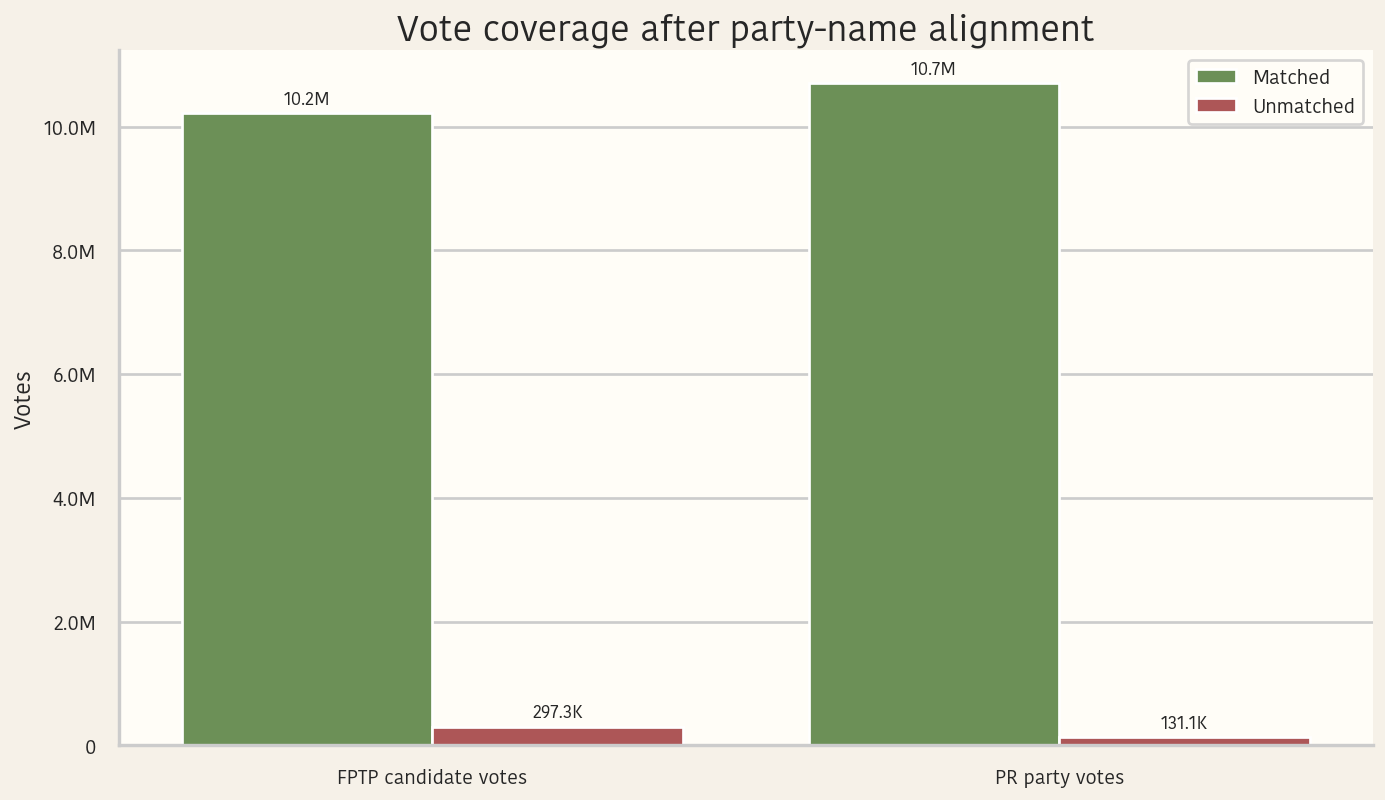

In [130]:
coverage_chart = pd.DataFrame({
    "dataset": ["FPTP candidate votes", "FPTP candidate votes", "PR party votes", "PR party votes"],
    "status": ["Matched", "Unmatched", "Matched", "Unmatched"],
    "votes": [
        matched["fptp_votes"].sum(),
        unmatched_fptp["fptp_votes"].sum(),
        matched["pr_votes"].sum(),
        unmatched_pr["pr_votes"].sum(),
    ],
})

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(
    data=coverage_chart,
    x="dataset",
    y="votes",
    hue="status",
    palette={"Matched": "#6a994e", "Unmatched": "#bc4749"},
    ax=ax,
)
ax.set_title("Vote coverage after party-name alignment")
ax.set_xlabel("")
ax.set_ylabel("Votes")
ax.yaxis.set_major_formatter(approx_formatter())
ax.legend(title="")
add_value_labels(ax, coverage_chart["votes"], exact=False, axis="y")
sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_alignment_coverage.png")
plt.show()

Matched parties cover nearly the full vote pool in both files, which means the party-level comparison is broad rather than selective. The remaining unmatched portion is still shown in the notebook, but it is small enough that the main patterns are not being driven by omitted records.

## Overall Vote Comparison

These views compare the biggest parties across the two vote systems. Broad overview figures use approximate number formatting to keep the axes readable while still preserving scale.

Exported Images/vote_type_overall_grouped_votes.png


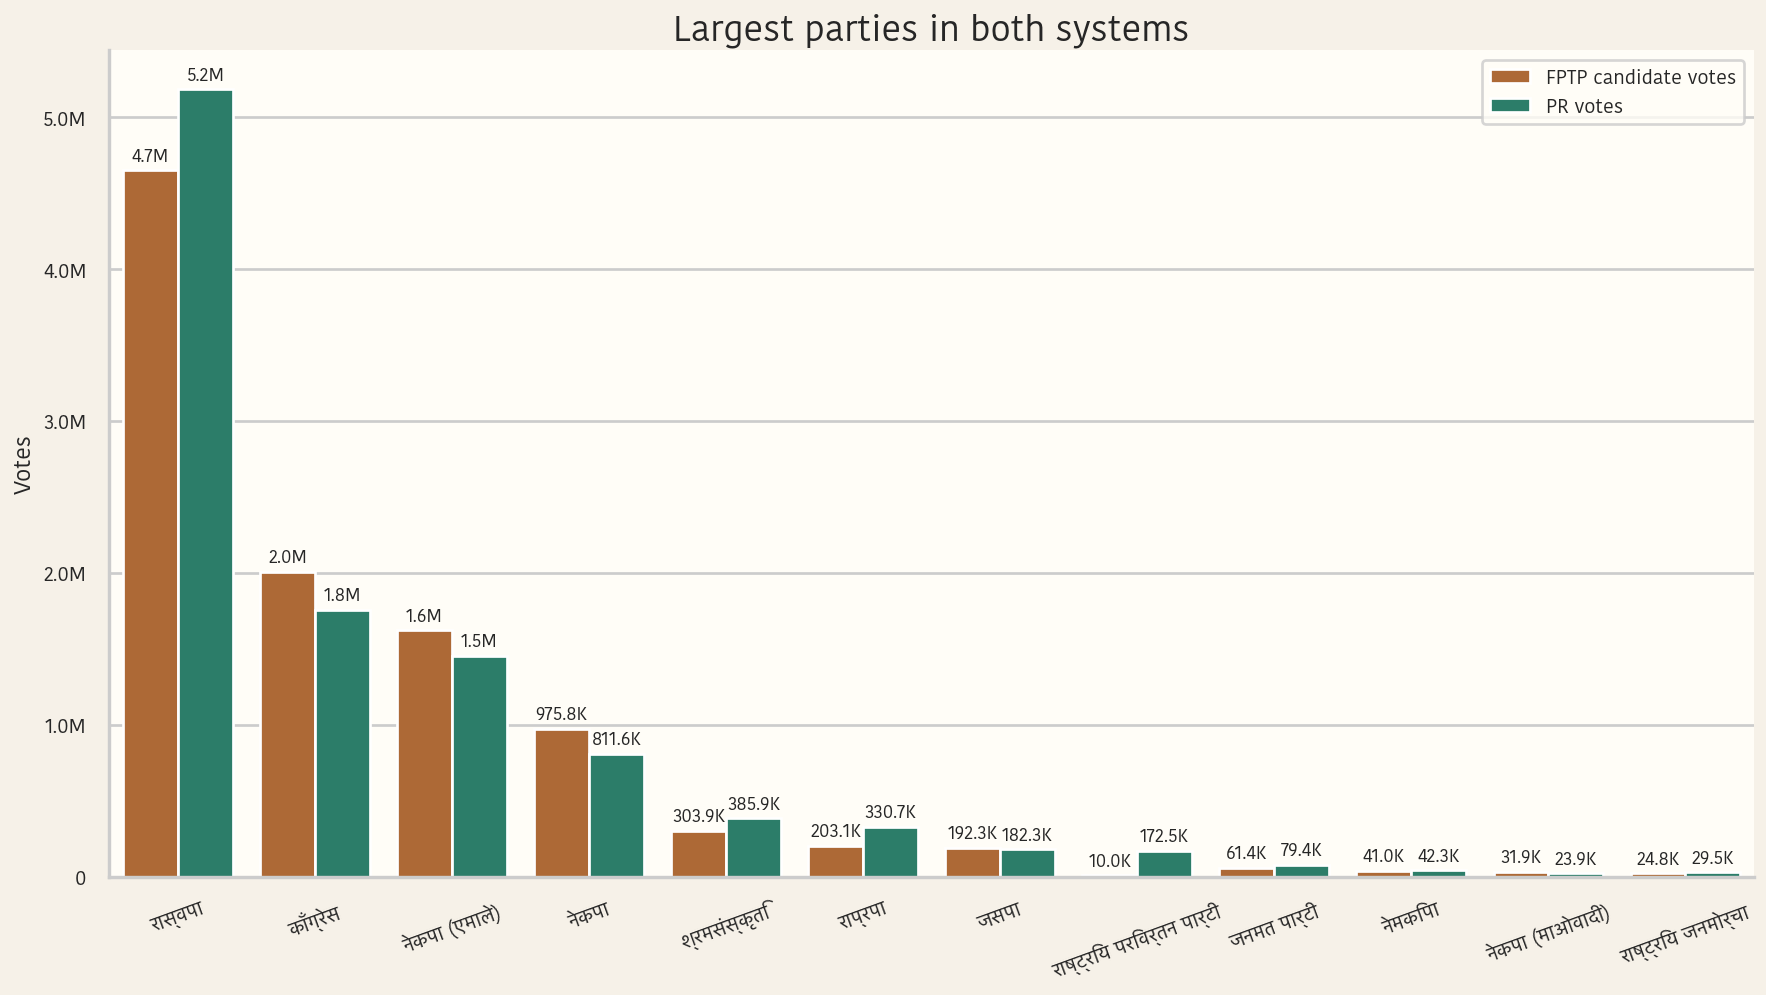

In [131]:
overview = matched.sort_values("combined_votes", ascending=False).head(12).copy()
overview["party_display"] = overview["party_name"].map(axis_party_label)
overview_long = overview.melt(
    id_vars=["party_name", "party_display"],
    value_vars=["fptp_votes", "pr_votes"],
    var_name="vote_type",
    value_name="votes",
)
overview_long["vote_type"] = overview_long["vote_type"].map({
    "fptp_votes": "FPTP candidate votes",
    "pr_votes": "PR votes",
})

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=overview_long,
    x="party_display",
    y="votes",
    hue="vote_type",
    palette={"FPTP candidate votes": "#c16622", "PR votes": "#1f8a70"},
    ax=ax,
)
ax.set_title("Largest parties in both systems")
ax.set_xlabel("")
ax.set_ylabel("Votes")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(approx_formatter())
ax.legend(title="")
add_value_labels(ax, overview_long["votes"], exact=False, axis="y")
sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_overall_grouped_votes.png")
plt.show()

The overall ranking is similar across systems at the top, but not identical. Some parties remain large in both pools, while others clearly perform better in constituency aggregation or in the national proportional ballot.

Exported Images/vote_type_overall_grouped_vote_shares.png


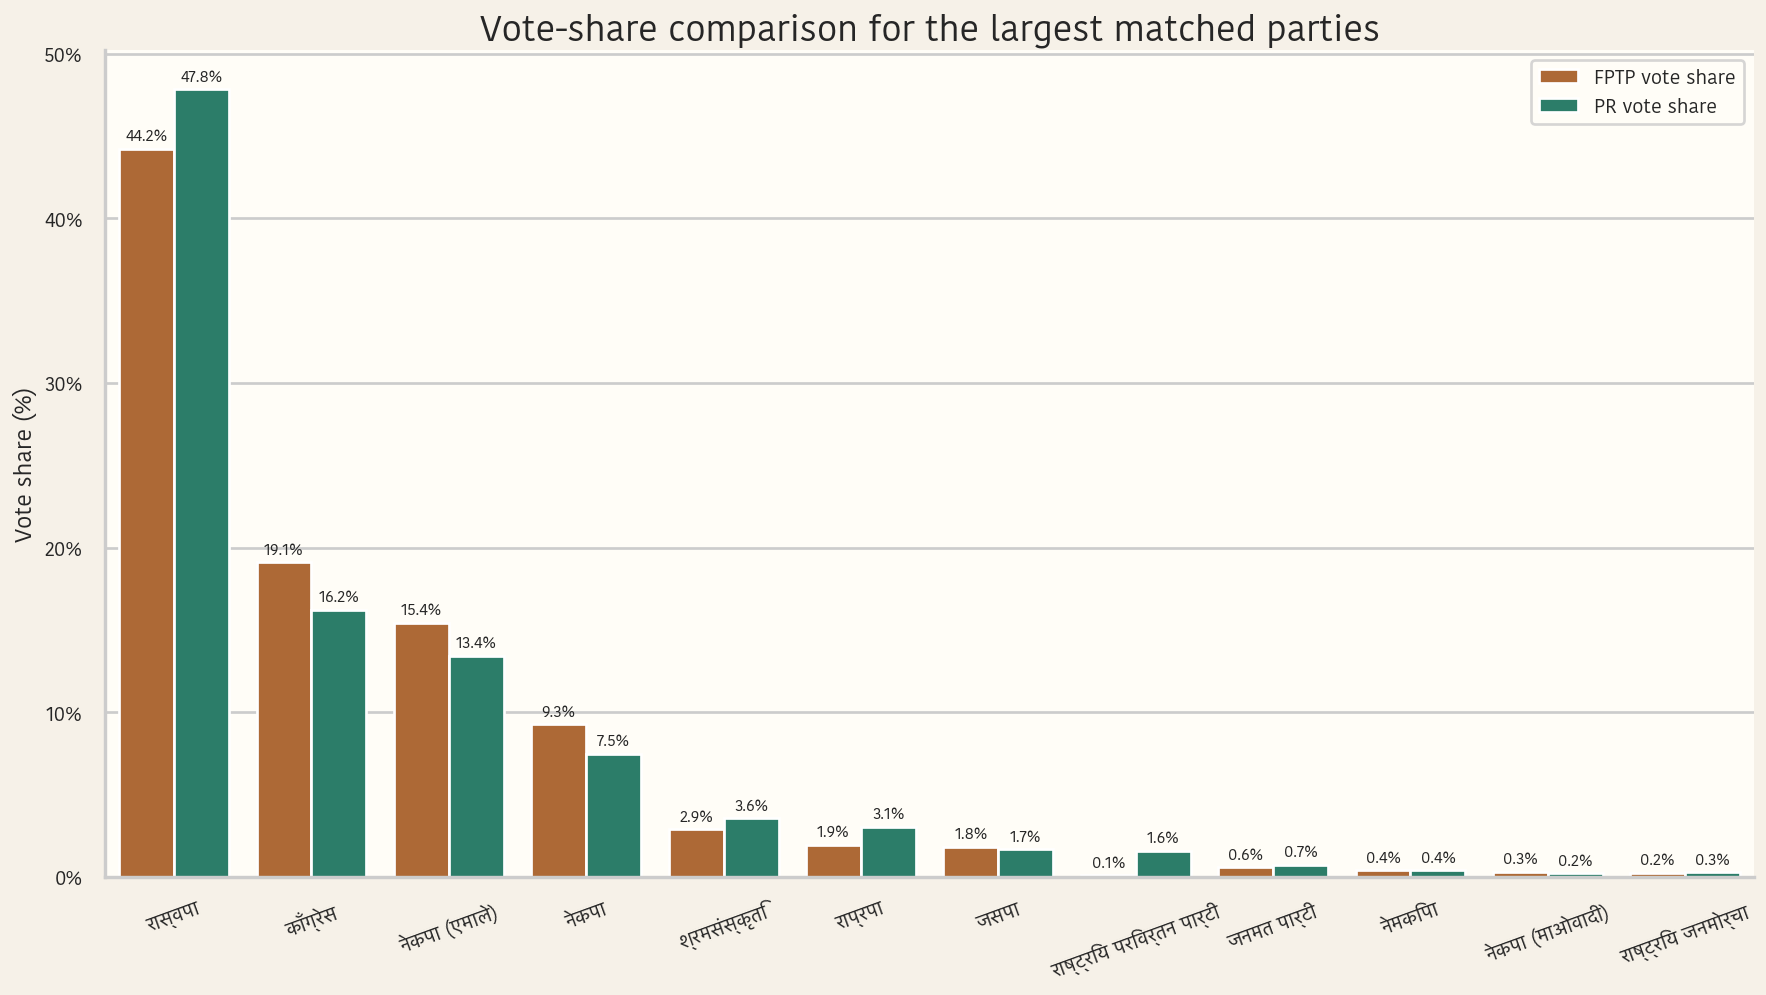

In [132]:
share_view = matched.sort_values("combined_votes", ascending=False).head(12).copy()
share_view["party_display"] = share_view["party_name"].map(axis_party_label)
share_long = share_view.melt(
    id_vars=["party_name", "party_display"],
    value_vars=["fptp_share", "pr_share"],
    var_name="vote_type",
    value_name="vote_share",
)
share_long["vote_type"] = share_long["vote_type"].map({
    "fptp_share": "FPTP vote share",
    "pr_share": "PR vote share",
})
share_long["vote_share_pct"] = share_long["vote_share"] * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=share_long,
    x="party_display",
    y="vote_share_pct",
    hue="vote_type",
    palette={"FPTP vote share": "#c16622", "PR vote share": "#1f8a70"},
    ax=ax,
)
ax.set_title("Vote-share comparison for the largest matched parties")
ax.set_xlabel("")
ax.set_ylabel("Vote share (%)")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}%"))
ax.legend(title="")
for container in ax.containers:
    labels = [f"{bar.get_height():.1f}%" for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)
sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_overall_grouped_vote_shares.png")
plt.show()

A party can hold a similar absolute scale in both systems but still shift its **share** of the vote noticeably. This view makes those proportional differences much easier to see than the raw-vote chart alone.

## Selected-Party Exact Comparison

The next section zooms in on six parties only:

- राष्ट्रिय स्वतन्त्र पार्टी
- नेपाली काँग्रेस
- नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी लेनिनवादी)
- नेपाली कम्युनिष्ट पार्टी
- श्रम संस्कृति पार्टी
- राष्ट्रिय प्रजातन्त्र पार्टी

In this focused section the notebook switches to exact number labels rather than approximate notation.

,Party,Exact FPTP votes,Exact PR votes,FPTP share %,PR share %,FPTP seats,Estimated PR seats,Estimated total seats,FPTP minus PR votes
69,राष्ट्रिय स्वतन्त्र पार्टी,"4,650,500","5,183,493",44.22,47.84,125,57,182,"-532,993"
40,नेपाली काँग्रेस,"2,008,619","1,759,172",19.10,16.24,18,20,38,"+249,447"
22,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी लेनिनवादी),"1,623,014","1,455,885",15.43,13.44,9,16,25,"+167,129"
39,नेपाली कम्युनिष्ट पार्टी,"975,813","811,577",9.28,7.49,8,9,17,"+164,236"
70,श्रम संस्कृति पार्टी,"303,872","385,902",2.89,3.56,3,4,7,"-82,030"
63,राष्ट्रिय प्रजातन्त्र पार्टी,"203,123","330,684",1.93,3.05,1,4,5,"-127,561"


Exported Images/vote_type_selected_exact_votes.png


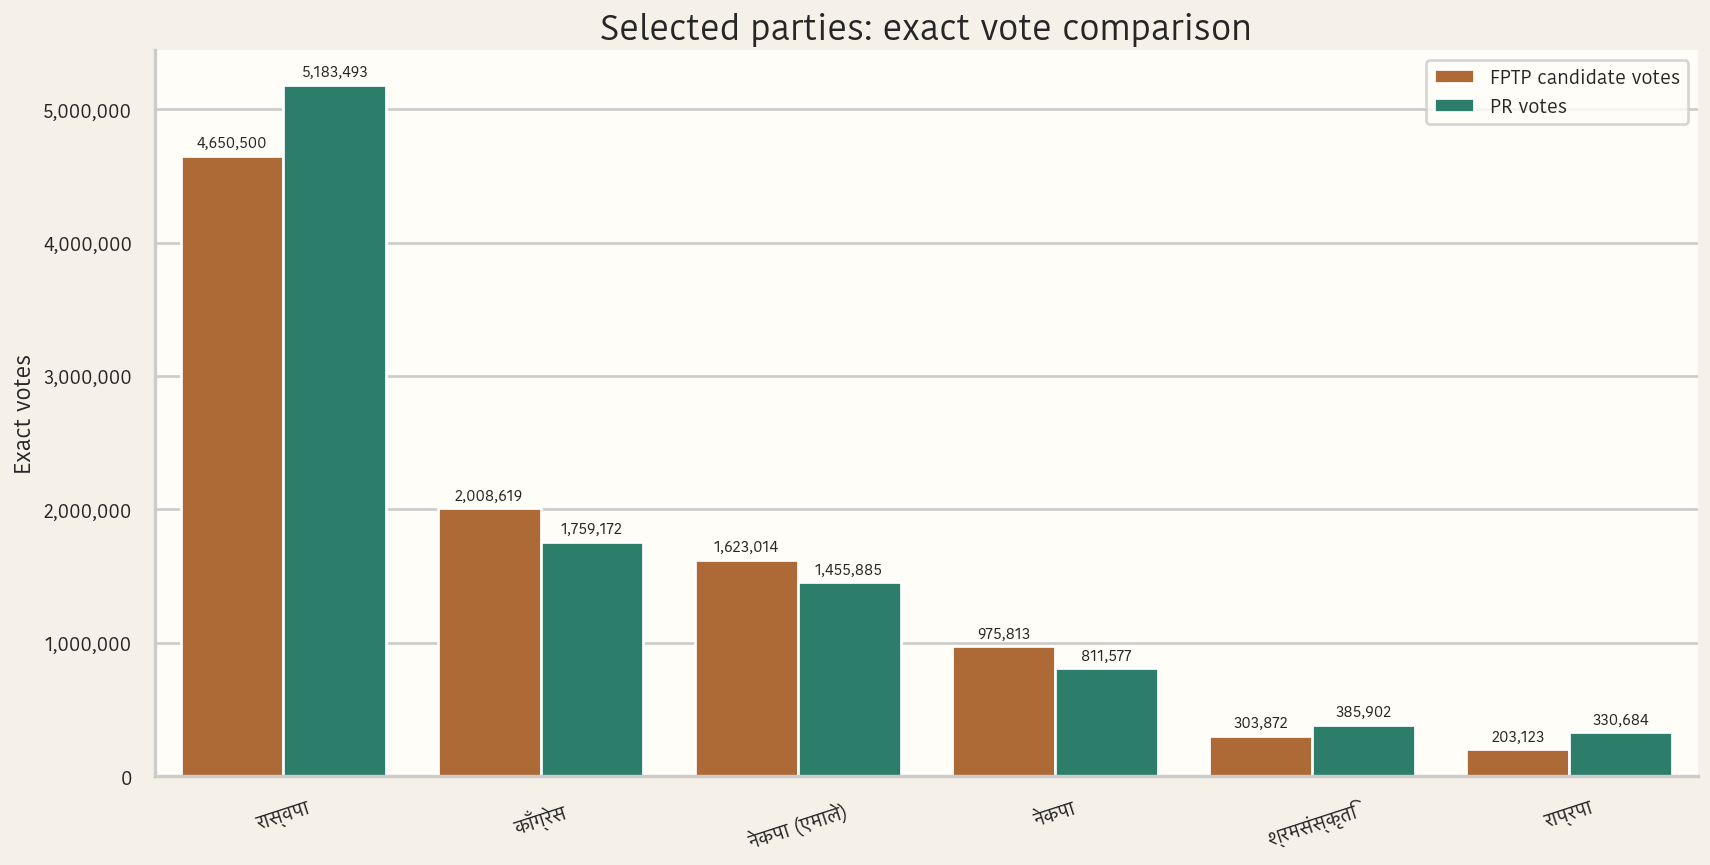

In [133]:
selected_dashboard = selected_party_view[
    [
        "party_name",
        "fptp_votes",
        "pr_votes",
        "fptp_share_pct",
        "pr_share_pct",
        "fptp_seats",
        "pr_projected_seats",
        "total_projected_seats",
        "system_difference_votes",
    ]
].copy()
selected_dashboard = selected_dashboard.rename(columns={
    "party_name": "Party",
    "fptp_votes": "Exact FPTP votes",
    "pr_votes": "Exact PR votes",
    "fptp_share_pct": "FPTP share %",
    "pr_share_pct": "PR share %",
    "fptp_seats": "FPTP seats",
    "pr_projected_seats": "Estimated PR seats",
    "total_projected_seats": "Estimated total seats",
    "system_difference_votes": "FPTP minus PR votes",
})
display(selected_dashboard.style.format({
    "Exact FPTP votes": "{:,.0f}",
    "Exact PR votes": "{:,.0f}",
    "FPTP share %": "{:.2f}",
    "PR share %": "{:.2f}",
    "FPTP seats": "{:,.0f}",
    "Estimated PR seats": "{:,.0f}",
    "Estimated total seats": "{:,.0f}",
    "FPTP minus PR votes": "{:+,.0f}",
}))

selected_party_view["party_display"] = selected_party_view["party_name"].map(axis_party_label)

selected_votes_long = selected_party_view.melt(
    id_vars=["party_name", "party_display"],
    value_vars=["fptp_votes", "pr_votes"],
    var_name="vote_type",
    value_name="votes",
)
selected_votes_long["vote_type"] = selected_votes_long["vote_type"].map({
    "fptp_votes": "FPTP candidate votes",
    "pr_votes": "PR votes",
})

fig, ax = plt.subplots(figsize=(13.5, 7))
sns.barplot(
    data=selected_votes_long,
    x="party_display",
    y="votes",
    hue="vote_type",
    palette={"FPTP candidate votes": "#c16622", "PR votes": "#1f8a70"},
    ax=ax,
)
ax.set_title("Selected parties: exact vote comparison")
ax.set_xlabel("")
ax.set_ylabel("Exact votes")
ax.tick_params(axis="x", rotation=18)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.legend(title="")
for container in ax.containers:
    labels = [f"{bar.get_height():,.0f}" for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)
sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_selected_exact_votes.png")
plt.show()

The selected-party panel makes the scale relationships explicit. The gap between FPTP and PR is modest for some parties, but others show a clearly system-specific support profile.

Exported Images/vote_type_selected_exact_shares_and_gaps.png


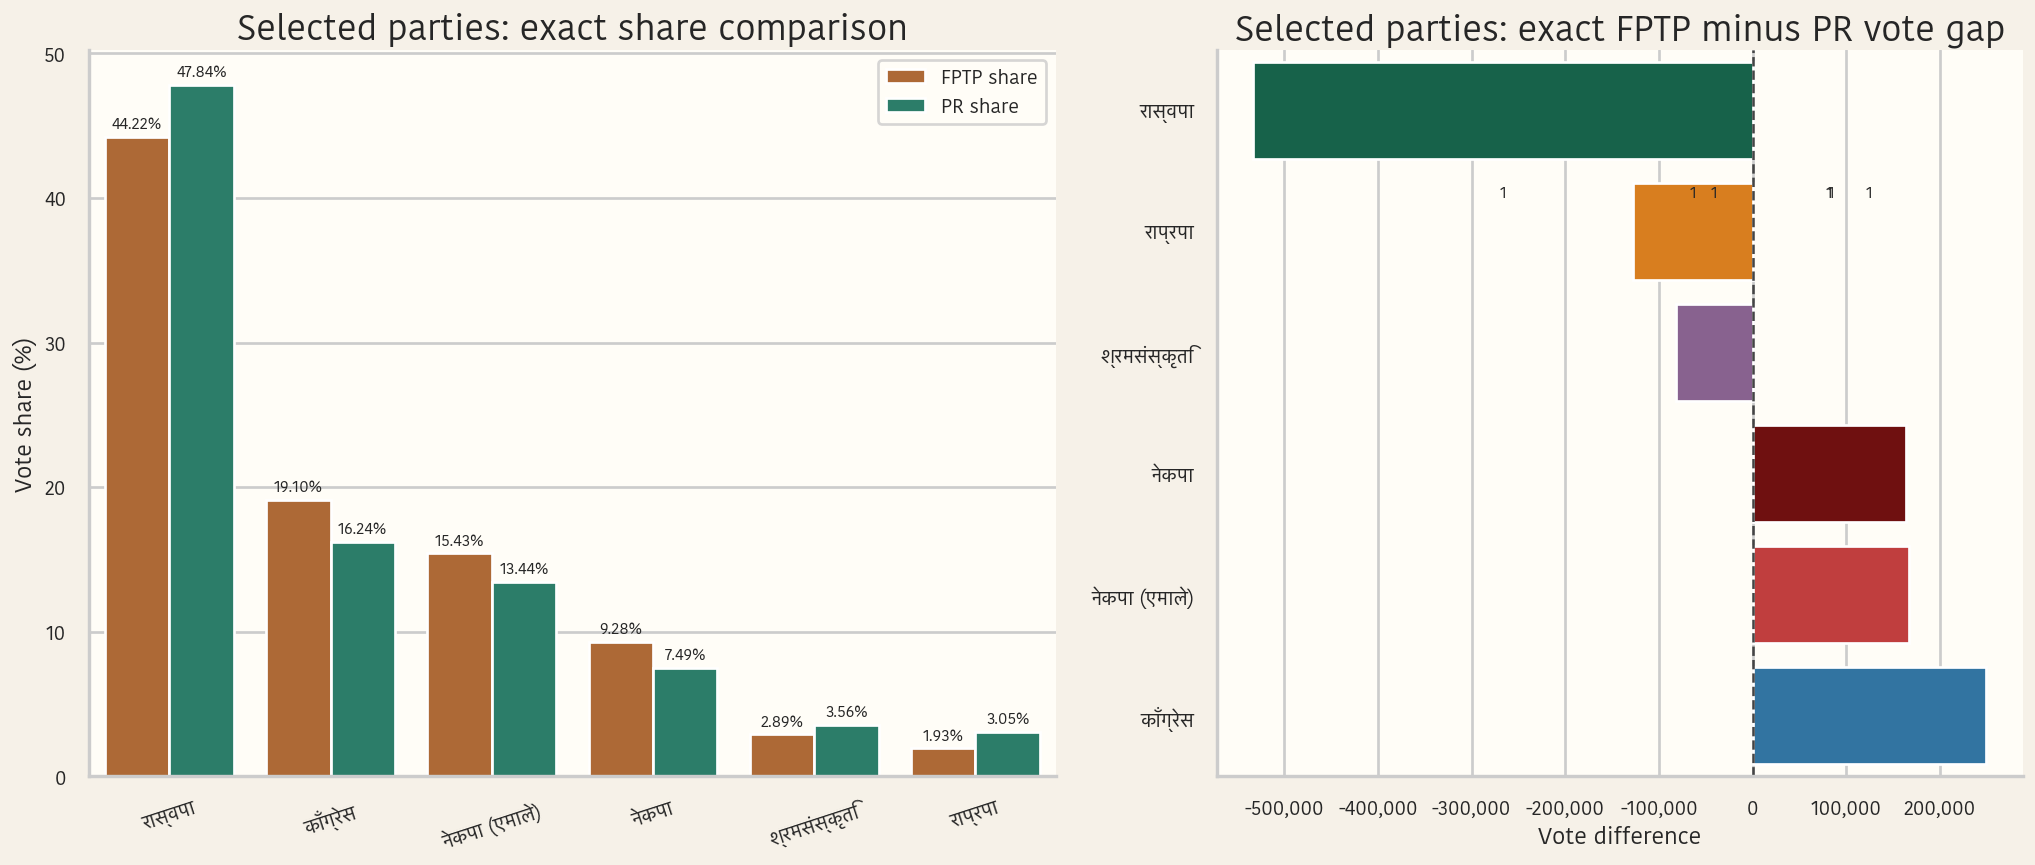

In [134]:
selected_party_view["party_display"] = selected_party_view["party_name"].map(axis_party_label)
selected_share_long = selected_party_view.melt(
    id_vars=["party_name", "party_display"],
    value_vars=["fptp_share_pct", "pr_share_pct"],
    var_name="share_type",
    value_name="share_pct",
)
selected_share_long["share_type"] = selected_share_long["share_type"].map({
    "fptp_share_pct": "FPTP share",
    "pr_share_pct": "PR share",
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.2, 1]})

sns.barplot(
    data=selected_share_long,
    x="party_display",
    y="share_pct",
    hue="share_type",
    palette={"FPTP share": "#c16622", "PR share": "#1f8a70"},
    ax=axes[0],
)
axes[0].set_title("Selected parties: exact share comparison")
axes[0].set_xlabel("")
axes[0].set_ylabel("Vote share (%)")
axes[0].tick_params(axis="x", rotation=18)
axes[0].legend(title="")
for container in axes[0].containers:
    labels = [f"{bar.get_height():.2f}%" for bar in container]
    axes[0].bar_label(container, labels=labels, padding=3, fontsize=9)

delta_view = selected_party_view[["party_name", "party_display", "system_difference_votes"]].sort_values("system_difference_votes")
sns.barplot(
    data=delta_view,
    x="system_difference_votes",
    y="party_display",
    palette=[get_party_color(p) for p in delta_view["party_name"]],
    ax=axes[1],
)
axes[1].axvline(0, color="#444444", linestyle="--", linewidth=1.4)
axes[1].set_title("Selected parties: exact FPTP minus PR vote gap")
axes[1].set_xlabel("Vote difference")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
annotate_bars(axes[1], fmt="exact", fontsize=9)

sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_selected_exact_shares_and_gaps.png")
plt.show()

This focused comparison separates two related questions: who is larger overall, and who is structurally stronger in one ballot type than the other. That distinction matters later when seat conversion is considered.

## Vote Share and Structural System Differences

The charts below move from raw scale to system structure:

- Which parties are constituency-heavy?
- Which parties are more PR-oriented?
- How far does seat share drift away from combined vote share?

Exported Images/vote_type_structural_ratio.png


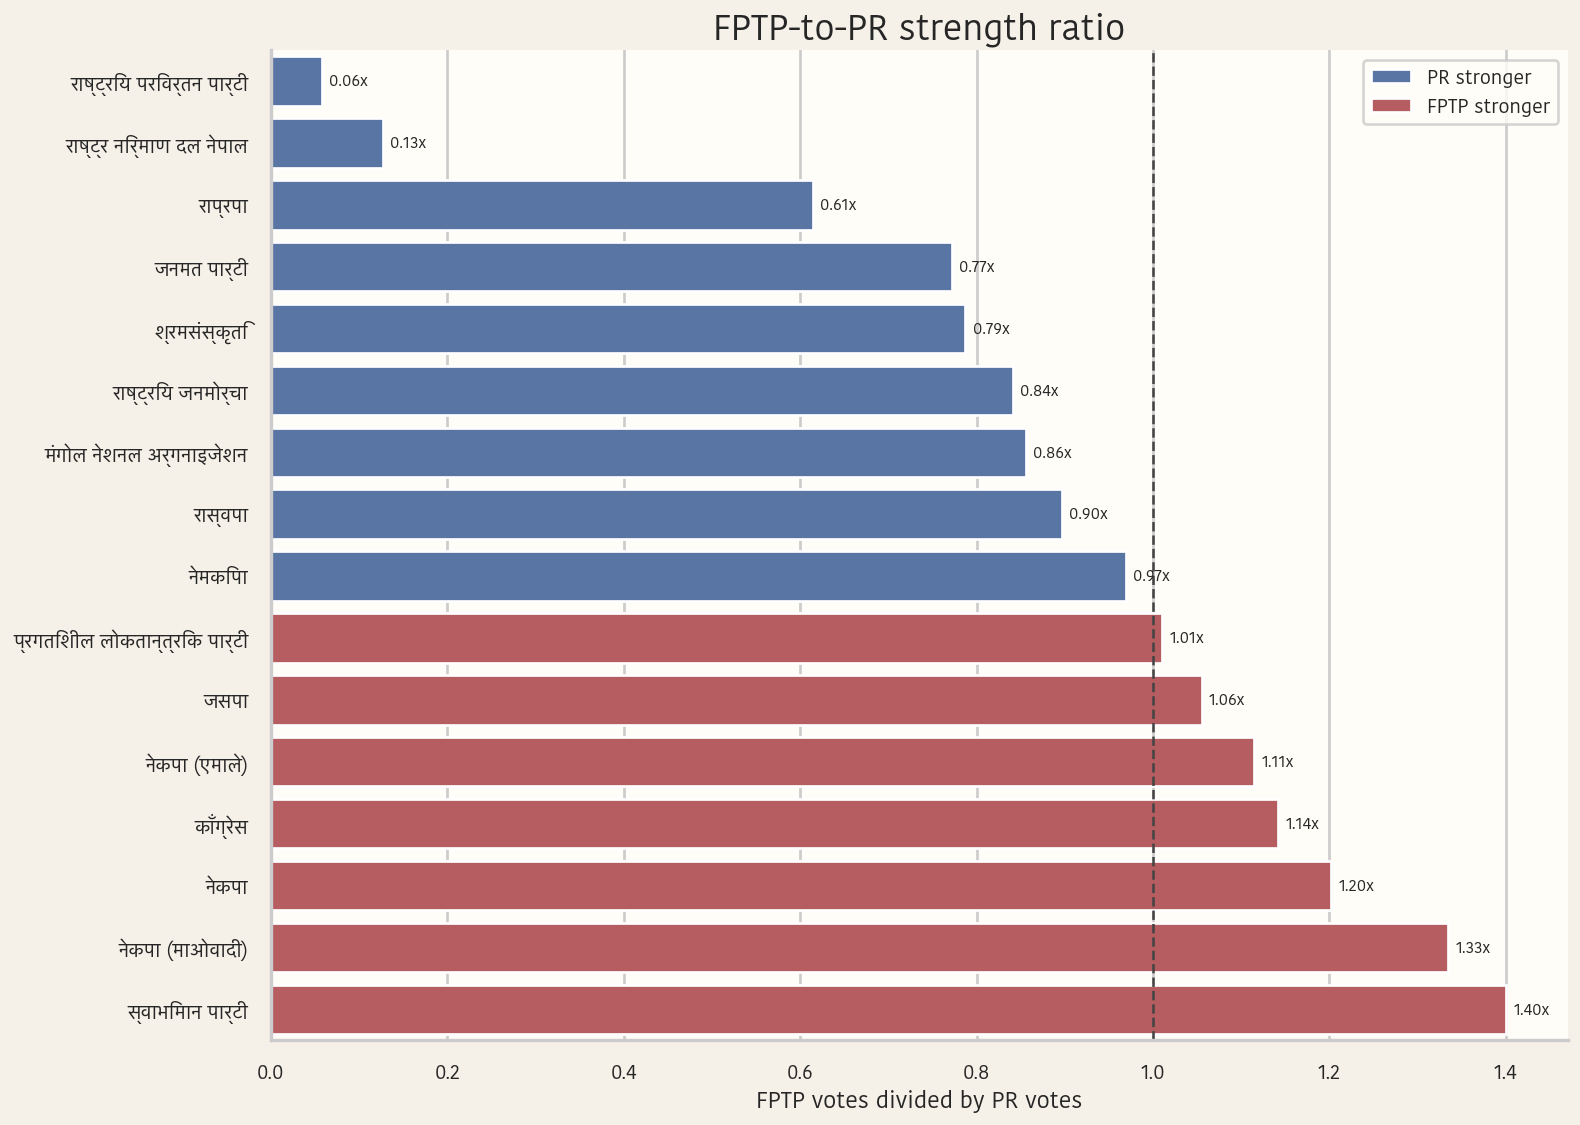

In [135]:
structural_view = matched[(matched["fptp_votes"] >= 5_000) & (matched["pr_votes"] >= 5_000)].copy()
structural_view["dominance_label"] = np.where(
    structural_view["fptp_to_pr_ratio"] >= 1,
    "FPTP stronger",
    "PR stronger",
)
ratio_focus = pd.concat([
    structural_view.nsmallest(8, "fptp_to_pr_ratio"),
    structural_view.nlargest(8, "fptp_to_pr_ratio"),
]).drop_duplicates().sort_values("fptp_to_pr_ratio")
ratio_focus["party_display"] = ratio_focus["party_name"].map(axis_party_label)

fig, ax = plt.subplots(figsize=(12.5, 9))
sns.barplot(
    data=ratio_focus,
    x="fptp_to_pr_ratio",
    y="party_display",
    hue="dominance_label",
    dodge=False,
    palette={"FPTP stronger": "#c44e52", "PR stronger": "#4c72b0"},
    ax=ax,
)
ax.axvline(1.0, color="#444444", linestyle="--", linewidth=1.4)
ax.set_title("FPTP-to-PR strength ratio")
ax.set_xlabel("FPTP votes divided by PR votes")
ax.set_ylabel("")
ax.legend(title="")
for container in ax.containers:
    labels = [f"{bar.get_width():.2f}x" for bar in container]
    ax.bar_label(container, labels=labels, padding=4, fontsize=9)
sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_structural_ratio.png")
plt.show()

The scatter view below focuses on the biggest matched parties and uses a distinct color for each party. Labels are moved to the legend so the points themselves stay readable.

Exported Images/vote_type_scatter_relationship.png


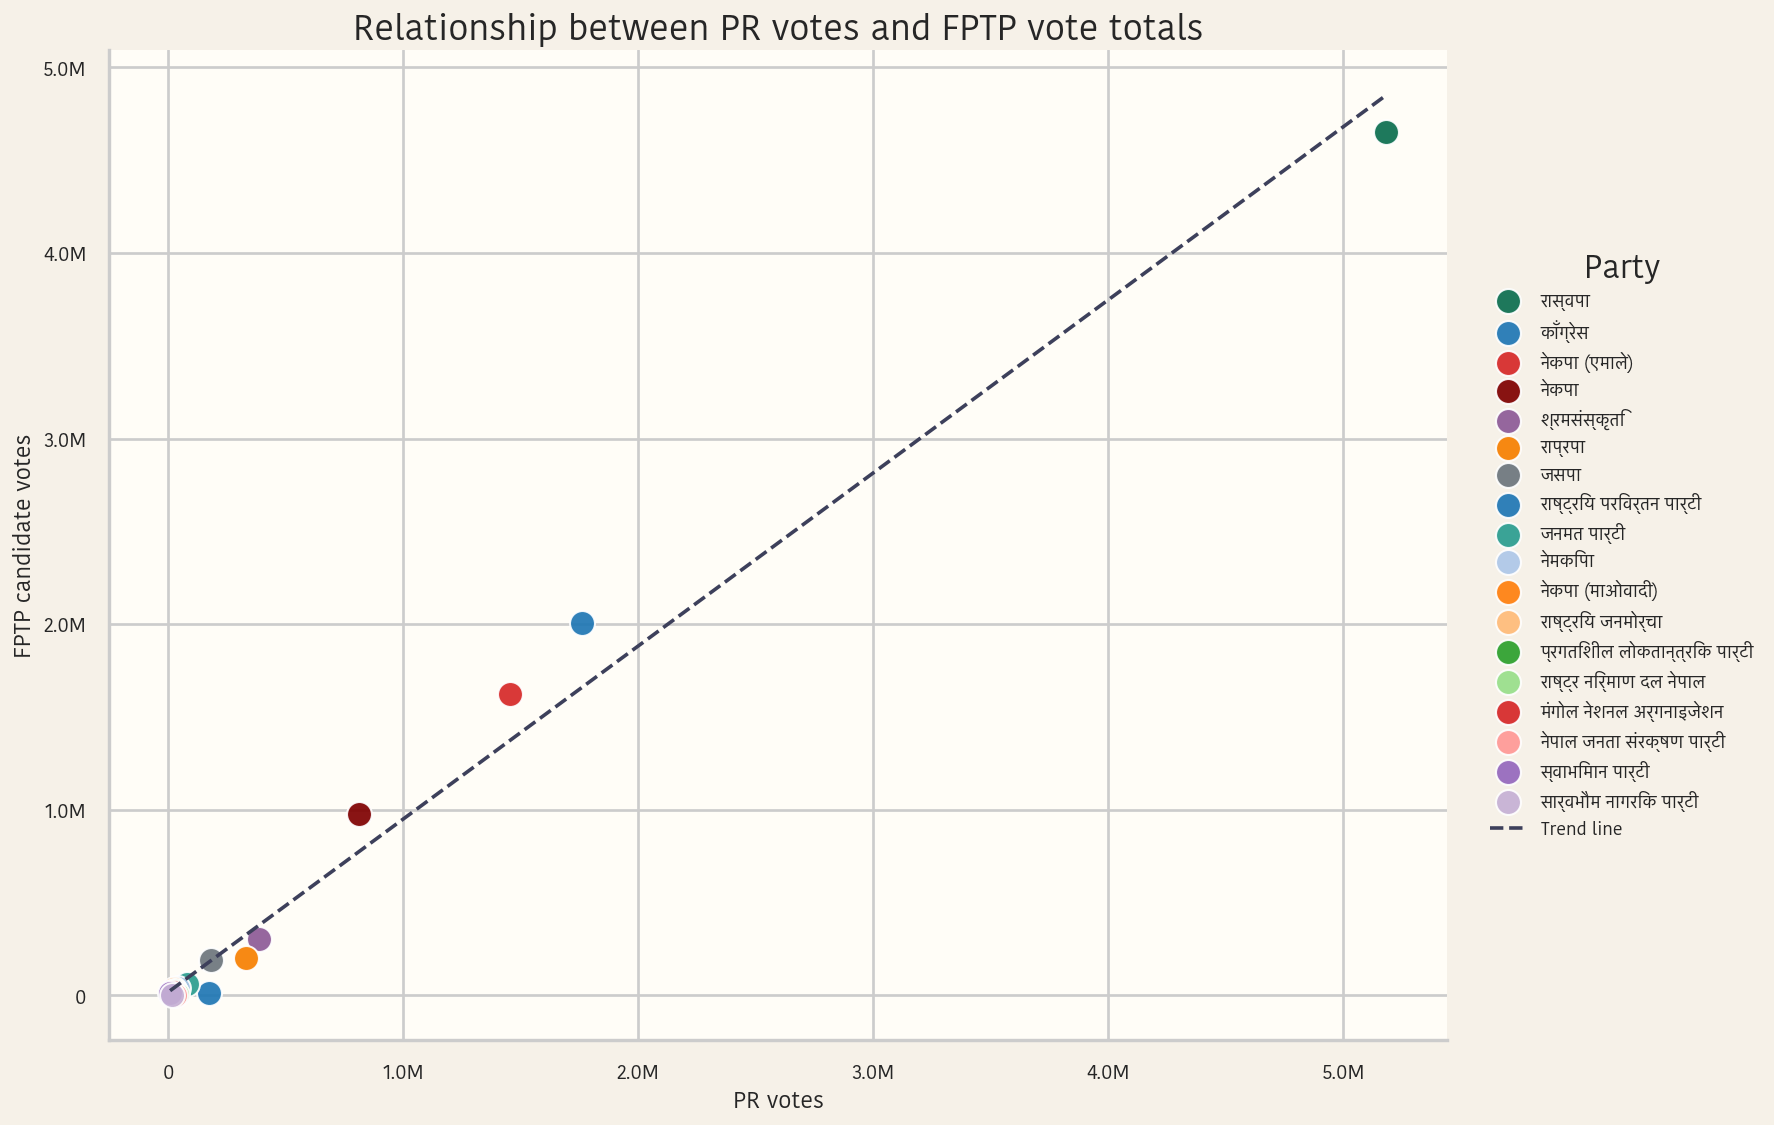

In [136]:
scatter_view = matched.sort_values("combined_votes", ascending=False).head(18).copy()

fig, ax = plt.subplots(figsize=(14, 9))
for _, row in scatter_view.iterrows():
    ax.scatter(
        row["pr_votes"],
        row["fptp_votes"],
        s=190,
        color=get_party_color(row["party_name"]),
        edgecolor="white",
        linewidth=1.1,
        alpha=0.92,
        label=axis_party_label(row["party_name"]),
    )

slope, intercept = np.polyfit(scatter_view["pr_votes"], scatter_view["fptp_votes"], 1)
line_x = np.linspace(scatter_view["pr_votes"].min(), scatter_view["pr_votes"].max(), 200)
ax.plot(line_x, slope * line_x + intercept, color="#3d405b", linewidth=2, linestyle="--", label="Trend line")
ax.set_title("Relationship between PR votes and FPTP vote totals")
ax.set_xlabel("PR votes")
ax.set_ylabel("FPTP candidate votes")
ax.xaxis.set_major_formatter(approx_formatter())
ax.yaxis.set_major_formatter(approx_formatter())
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    ncol=1,
    fontsize=10,
    title="Party",
)
sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_scatter_relationship.png")
plt.show()

Ratios above `1.0` indicate a party whose aggregated constituency vote total is stronger than its PR total. Ratios below `1.0` indicate the reverse. A minimum vote threshold is used here to avoid tiny-party distortions from very small denominators.

Exported Images/vote_type_vote_share_vs_seat_share.png


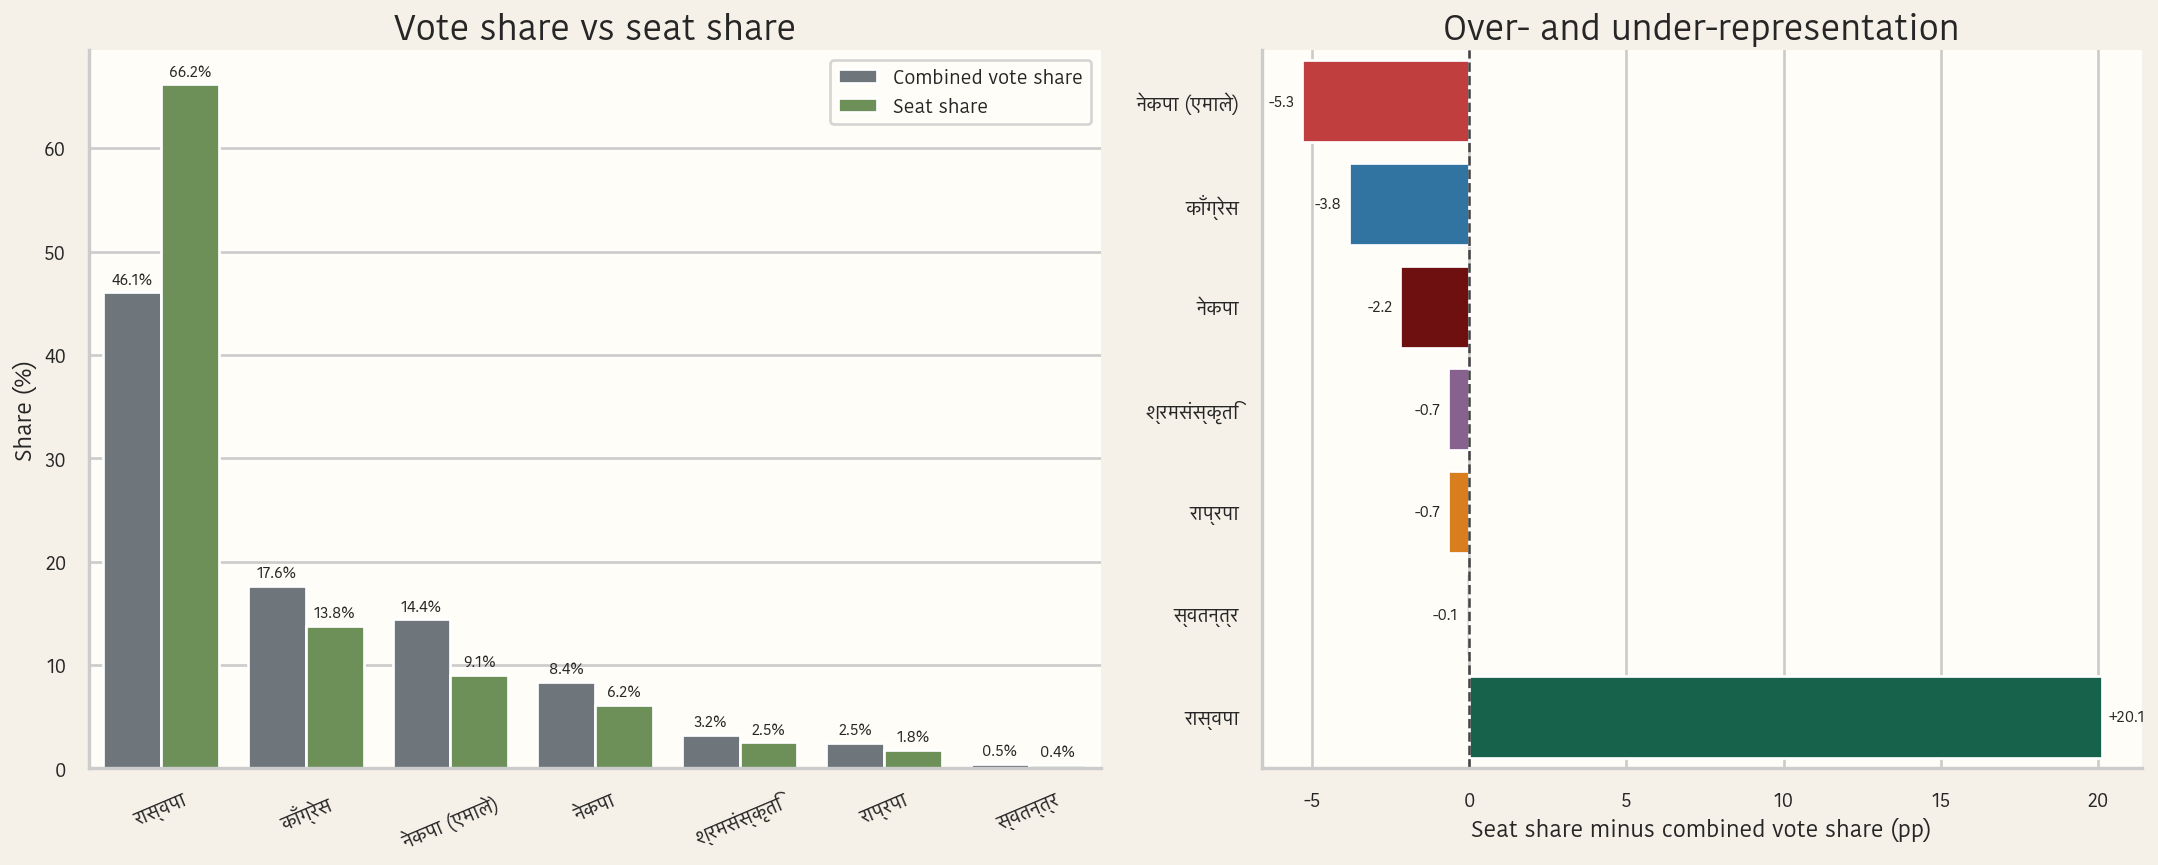

In [137]:
meaningful_seat_view = seat_outlook[seat_outlook["total_projected_seats"] > 0].sort_values("total_projected_seats", ascending=False).head(10).copy()
meaningful_seat_view["party_display"] = meaningful_seat_view["party_name"].map(axis_party_label)
vote_seat_long = meaningful_seat_view.melt(
    id_vars=["party_name", "party_display"],
    value_vars=["combined_vote_share", "seat_share"],
    var_name="metric",
    value_name="share",
)
vote_seat_long["metric"] = vote_seat_long["metric"].map({
    "combined_vote_share": "Combined vote share",
    "seat_share": "Seat share",
})
vote_seat_long["share_pct"] = vote_seat_long["share"] * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [1.15, 1]})

sns.barplot(
    data=vote_seat_long,
    x="party_display",
    y="share_pct",
    hue="metric",
    palette={"Combined vote share": "#6c757d", "Seat share": "#6a994e"},
    ax=axes[0],
)
axes[0].set_title("Vote share vs seat share")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share (%)")
axes[0].tick_params(axis="x", rotation=23)
axes[0].legend(title="")
for container in axes[0].containers:
    labels = [f"{bar.get_height():.1f}%" for bar in container]
    axes[0].bar_label(container, labels=labels, padding=3, fontsize=9)

gap_view = meaningful_seat_view.sort_values("representation_gap_pp")
sns.barplot(
    data=gap_view,
    x="representation_gap_pp",
    y="party_display",
    palette=[get_party_color(p) for p in gap_view["party_name"]],
    ax=axes[1],
)
axes[1].axvline(0, color="#444444", linestyle="--", linewidth=1.4)
axes[1].set_title("Over- and under-representation")
axes[1].set_xlabel("Seat share minus combined vote share (pp)")
axes[1].set_ylabel("")
for container in axes[1].containers:
    labels = [f"{bar.get_width():+.1f}" for bar in container]
    axes[1].bar_label(container, labels=labels, padding=4, fontsize=9)

sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_vote_share_vs_seat_share.png")
plt.show()

This is the core representation question. If a party’s seat share rises above its combined vote share, it is over-represented in the blended 275-seat outlook; if it falls below, it is under-represented.

Exported Images/vote_type_vote_efficiency.png


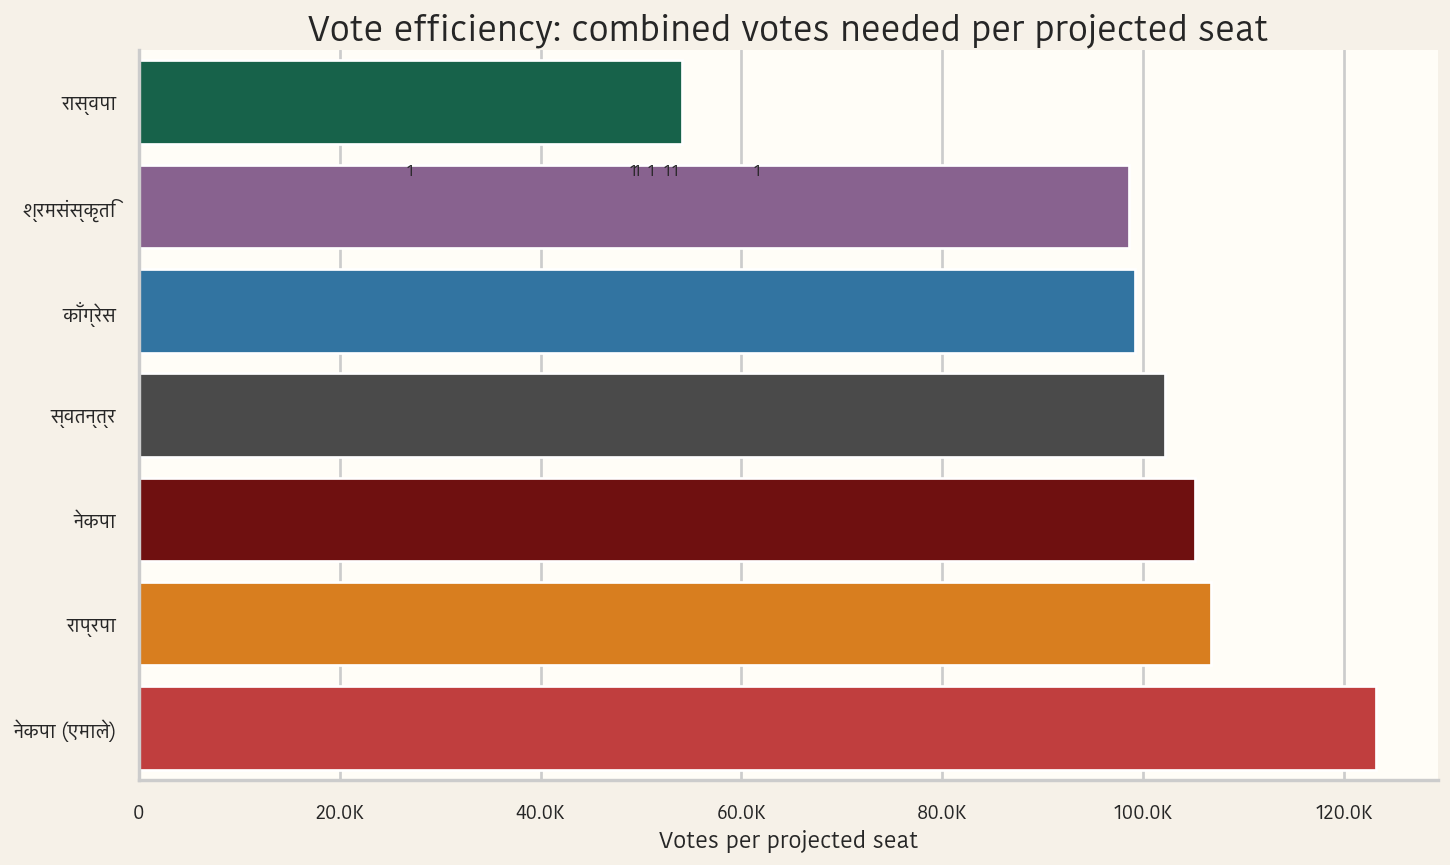

In [138]:
efficiency_view = seat_outlook[seat_outlook["total_projected_seats"] > 0].sort_values("votes_per_total_seat").copy()
efficiency_view["party_display"] = efficiency_view["party_name"].map(axis_party_label)

fig, ax = plt.subplots(figsize=(11.5, 7))
sns.barplot(
    data=efficiency_view.head(10),
    x="votes_per_total_seat",
    y="party_display",
    palette=[get_party_color(p) for p in efficiency_view.head(10)["party_name"]],
    ax=ax,
)
ax.set_title("Vote efficiency: combined votes needed per projected seat")
ax.set_xlabel("Votes per projected seat")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(approx_formatter())
annotate_bars(ax, fmt="approx", fontsize=9)
sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_vote_efficiency.png")
plt.show()

Lower values on this chart mean a party converts votes into seats more efficiently in the notebook’s combined seat outlook. This is descriptive rather than normative: it shows the seat model’s translation of support into representation.

## FPTP Winners and Seat Analysis

FPTP seats come directly from the official winner flags in the constituency results file. The next charts look at the winner distribution and then compare direct FPTP wins with the notebook’s PR-seat approximation.

Exported Images/vote_type_fptp_and_combined_seat_composition.png


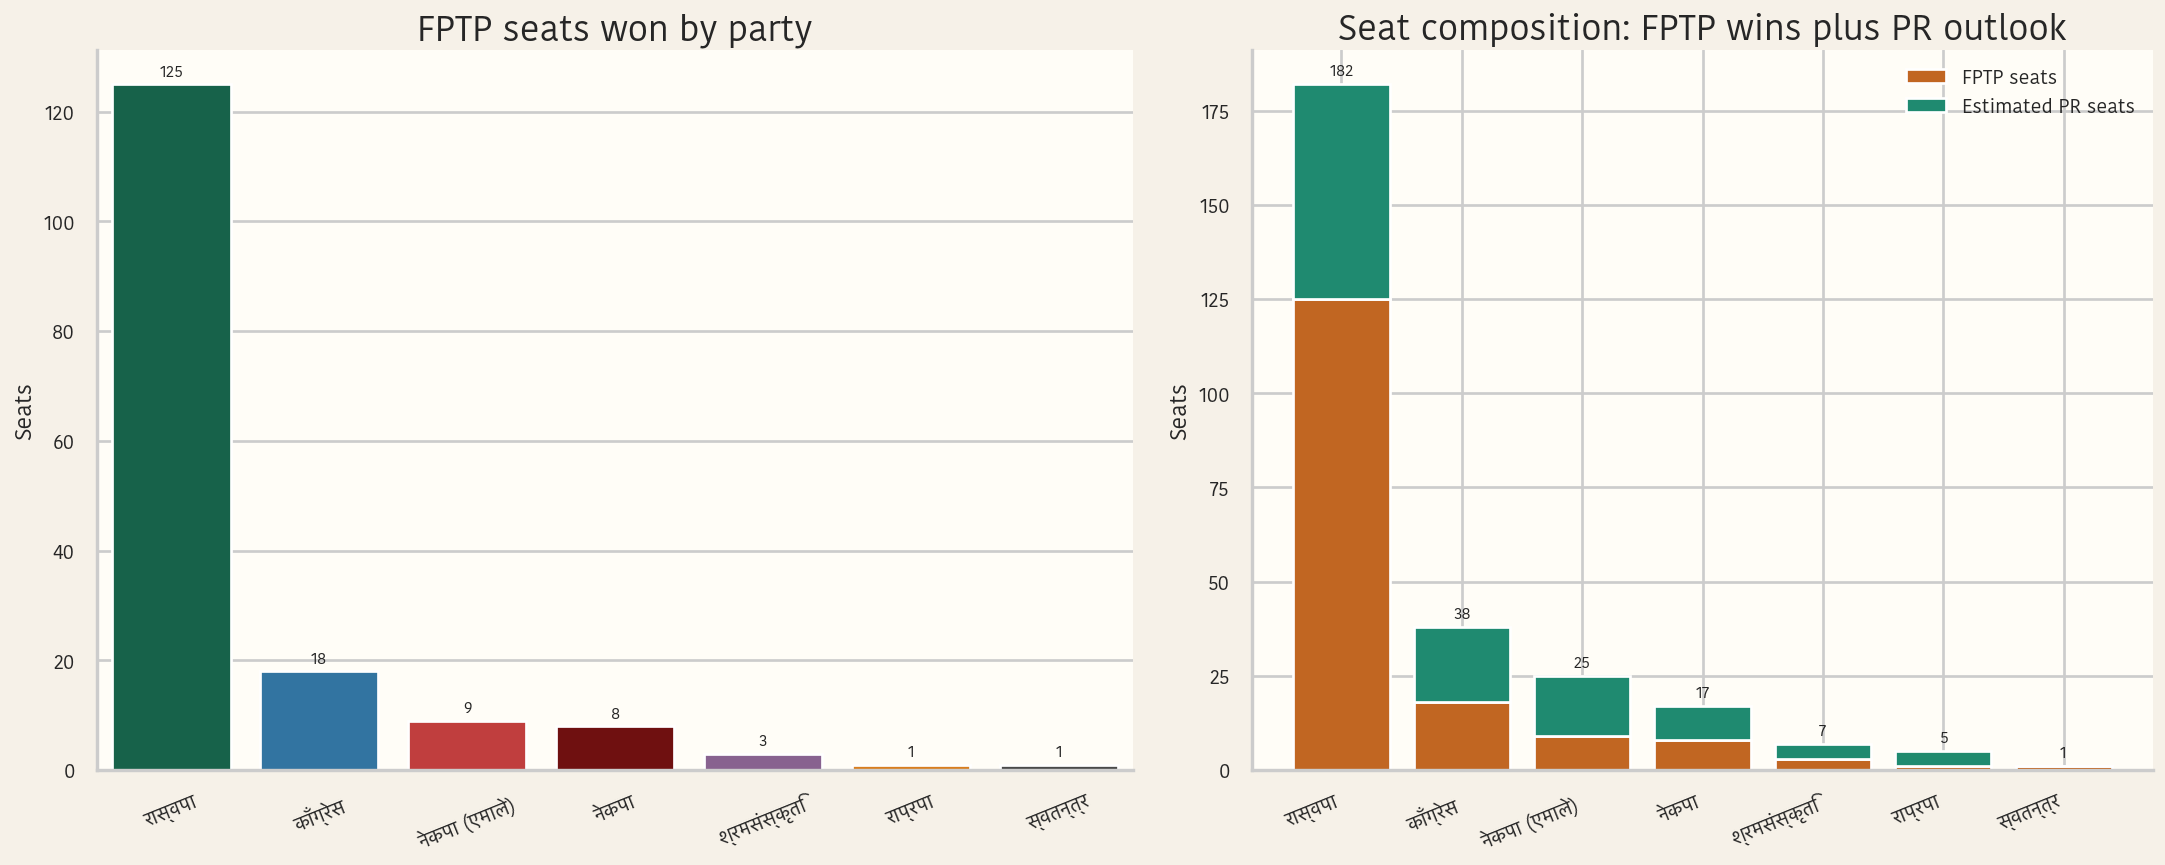

In [139]:
winner_summary = seat_outlook[seat_outlook["fptp_seats"] > 0].sort_values("fptp_seats", ascending=False).copy()
winner_summary["party_display"] = winner_summary["party_name"].map(axis_party_label)
winner_long = winner_summary.melt(
    id_vars=["party_name", "party_display"],
    value_vars=["fptp_seats", "pr_projected_seats"],
    var_name="seat_type",
    value_name="seats",
)
winner_long["seat_type"] = winner_long["seat_type"].map({
    "fptp_seats": "FPTP seats won",
    "pr_projected_seats": "Estimated PR seats",
})

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [1.15, 1]})

sns.barplot(
    data=winner_summary.head(10),
    x="party_display",
    y="fptp_seats",
    palette=[get_party_color(p) for p in winner_summary.head(10)["party_name"]],
    ax=axes[0],
)
axes[0].set_title("FPTP seats won by party")
axes[0].set_xlabel("")
axes[0].set_ylabel("Seats")
axes[0].tick_params(axis="x", rotation=22)
for container in axes[0].containers:
    labels = [f"{bar.get_height():.0f}" for bar in container]
    axes[0].bar_label(container, labels=labels, padding=3, fontsize=9)

stacked = seat_outlook[seat_outlook["total_projected_seats"] > 0].sort_values("total_projected_seats", ascending=False).head(10).copy()
stacked["party_display"] = stacked["party_name"].map(axis_party_label)
axes[1].bar(stacked["party_display"], stacked["fptp_seats"], color="#c16622", label="FPTP seats")
axes[1].bar(stacked["party_display"], stacked["pr_projected_seats"], bottom=stacked["fptp_seats"], color="#1f8a70", label="Estimated PR seats")
axes[1].set_title("Seat composition: FPTP wins plus PR outlook")
axes[1].set_xlabel("")
axes[1].set_ylabel("Seats")
axes[1].set_xticks(range(len(stacked)))
axes[1].set_xticklabels(stacked["party_display"], rotation=22, ha="right")
for i, total in enumerate(stacked["total_projected_seats"]):
    axes[1].text(i, total + 1.5, f"{int(total)}", ha="center", va="bottom", fontsize=9)
axes[1].legend(frameon=False)

sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_fptp_and_combined_seat_composition.png")
plt.show()

The left chart reflects direct constituency victories only. The right chart adds the proportional seat approximation, showing how a dominant FPTP lead may or may not expand further once PR votes are blended in.

## Victory Margin Analysis

Each constituency is reduced to a winner and runner-up to calculate victory margins. This section shows the overall distribution of competitiveness, the closest races, the largest landslides, and how winning margins vary across major winning parties.

Exported Images/vote_type_victory_margin_analysis.png


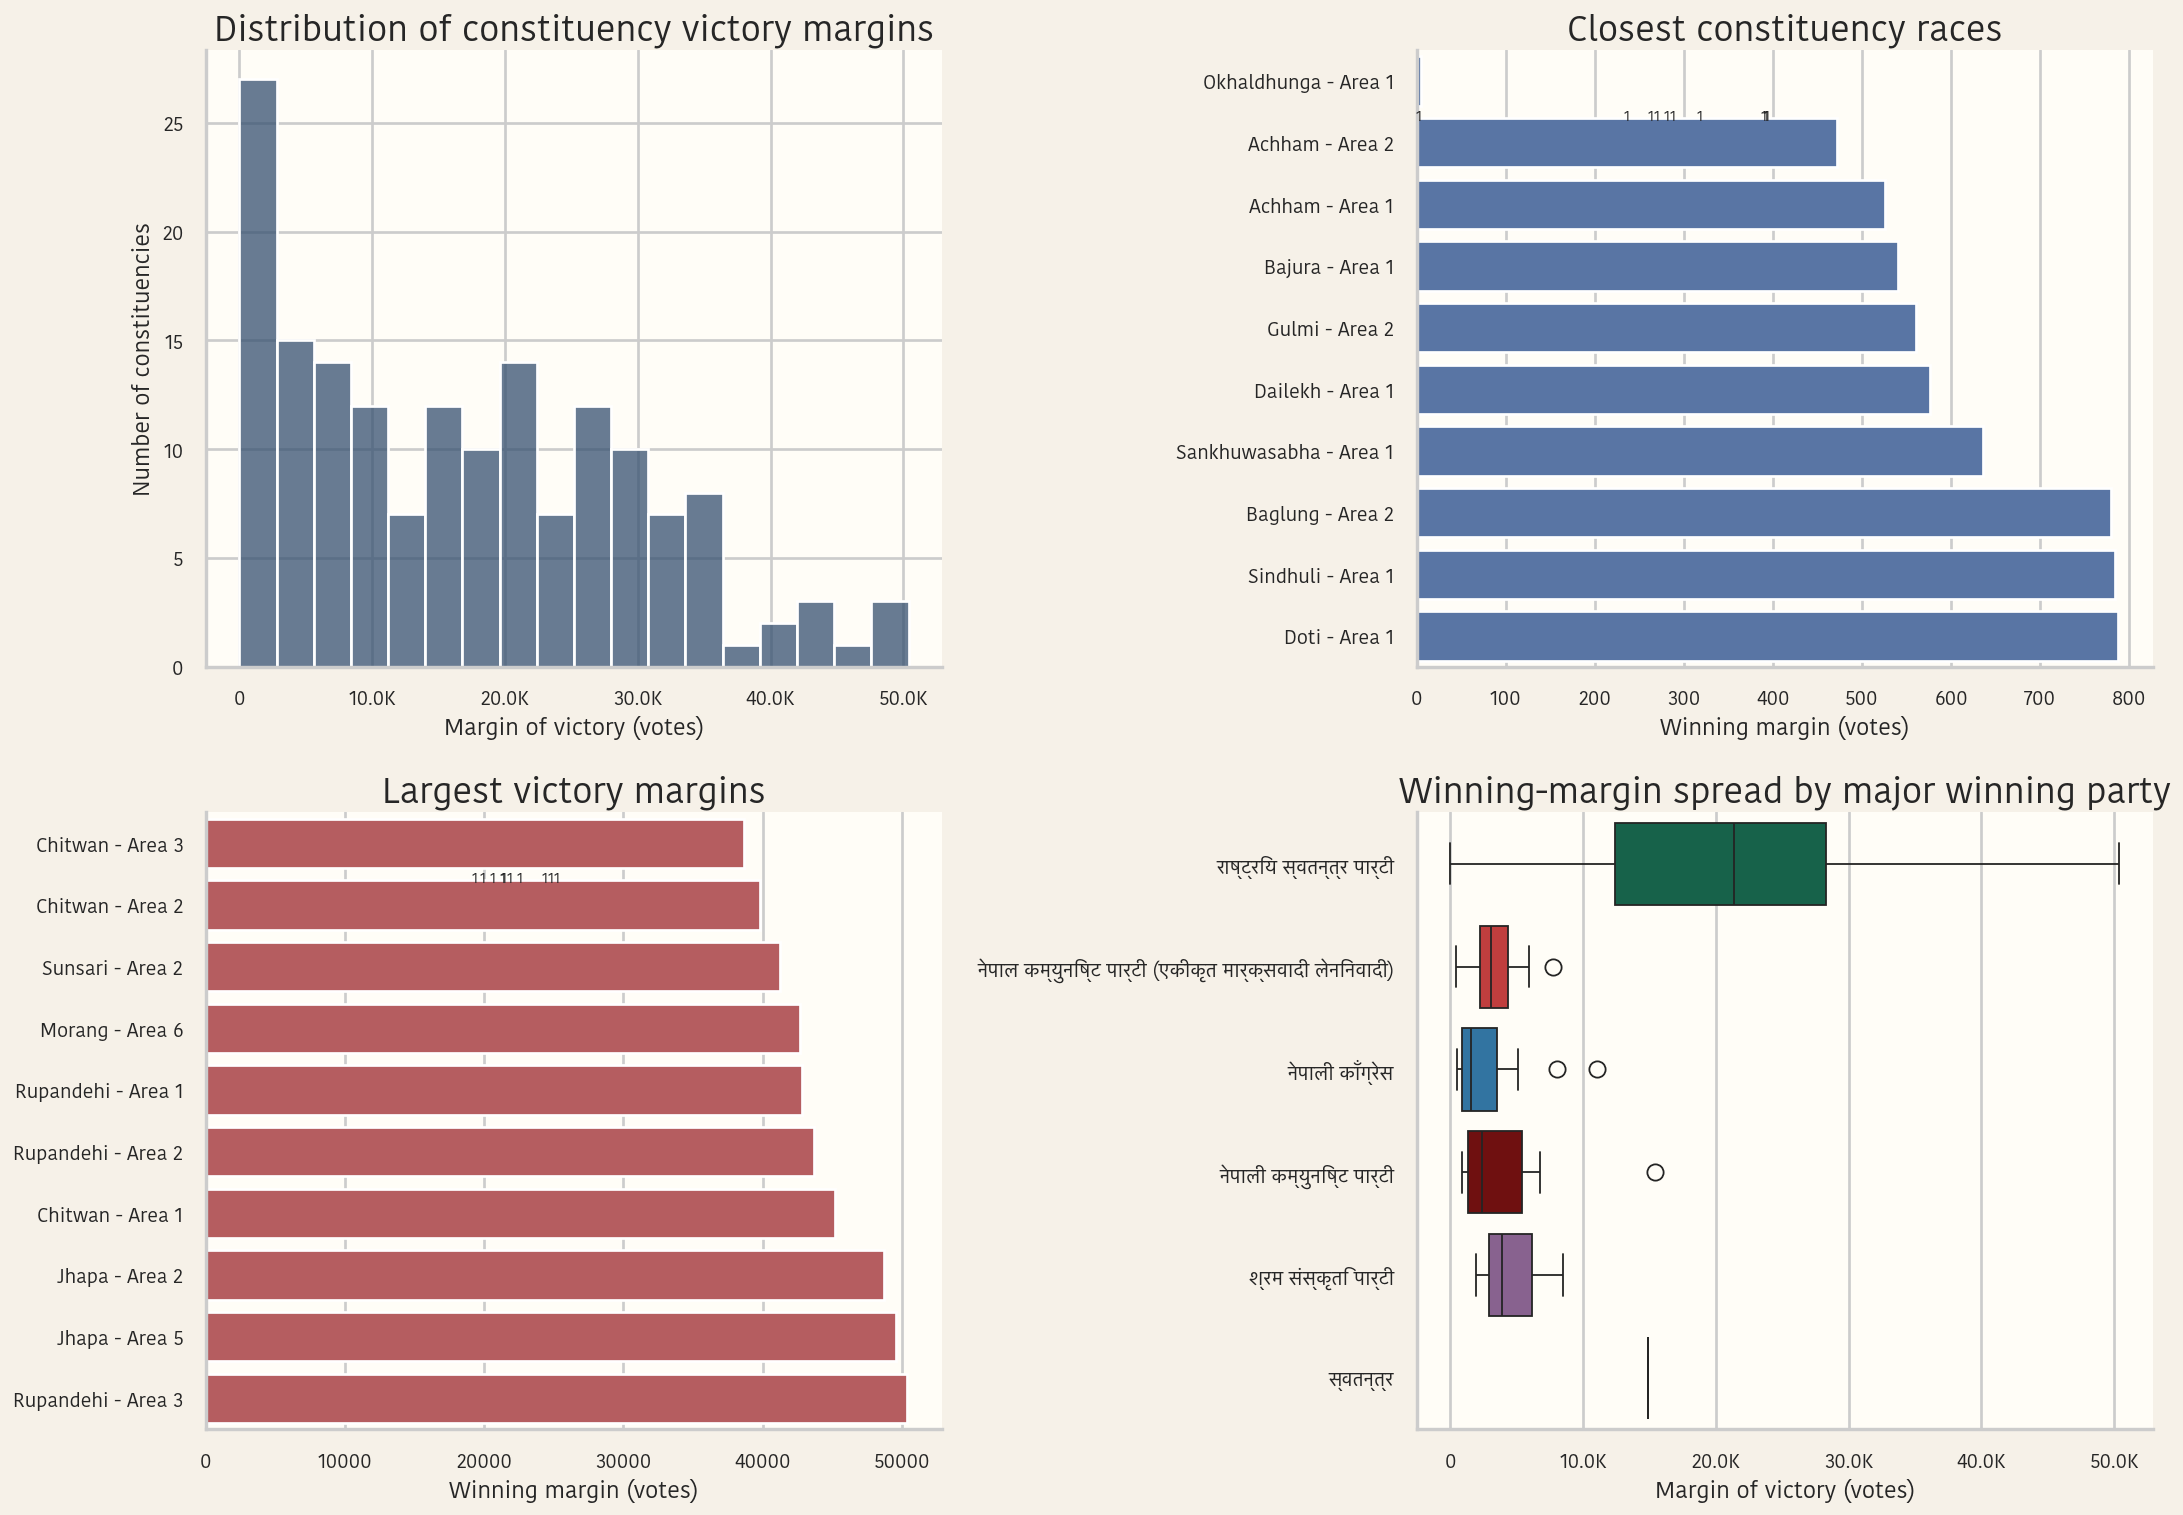

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

sns.histplot(margins["margin_votes"], bins=18, color="#355070", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of constituency victory margins")
axes[0, 0].set_xlabel("Margin of victory (votes)")
axes[0, 0].set_ylabel("Number of constituencies")
axes[0, 0].xaxis.set_major_formatter(approx_formatter())

closest = margins.nsmallest(10, "margin_votes").sort_values("margin_votes", ascending=True)
sns.barplot(data=closest, x="margin_votes", y="constituency", color="#4c72b0", ax=axes[0, 1])
axes[0, 1].set_title("Closest constituency races")
axes[0, 1].set_xlabel("Winning margin (votes)")
axes[0, 1].set_ylabel("")
annotate_bars(axes[0, 1], fmt="exact", fontsize=8)

landslides = margins.nlargest(10, "margin_votes").sort_values("margin_votes", ascending=True)
sns.barplot(data=landslides, x="margin_votes", y="constituency", color="#c44e52", ax=axes[1, 0])
axes[1, 0].set_title("Largest victory margins")
axes[1, 0].set_xlabel("Winning margin (votes)")
axes[1, 0].set_ylabel("")
annotate_bars(axes[1, 0], fmt="exact", fontsize=8)

margin_box = margins[margins["winner_party"].isin(fptp_winners["party_clean"].value_counts().head(6).index)].copy()
sns.boxplot(
    data=margin_box,
    x="margin_votes",
    y="winner_party",
    palette=[get_party_color(p) for p in margin_box["winner_party"].drop_duplicates()],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Winning-margin spread by major winning party")
axes[1, 1].set_xlabel("Margin of victory (votes)")
axes[1, 1].set_ylabel("")
axes[1, 1].xaxis.set_major_formatter(approx_formatter())

sns.despine()
plt.tight_layout()
export_figure(fig, "vote_type_victory_margin_analysis.png")
plt.show()

Close races identify constituencies where the seat outcome was highly contestable, while the landslide end shows where local dominance was strongest. The party boxplot adds a distributional view rather than only highlighting the most extreme cases.

## Provincial Strength Overview

Province-level aggregation helps show whether parties are broad-based or geographically concentrated. To keep the chart readable, the heatmap below focuses on the eight parties with the largest FPTP vote totals.

Exported Images/vote_type_province_heatmap.png


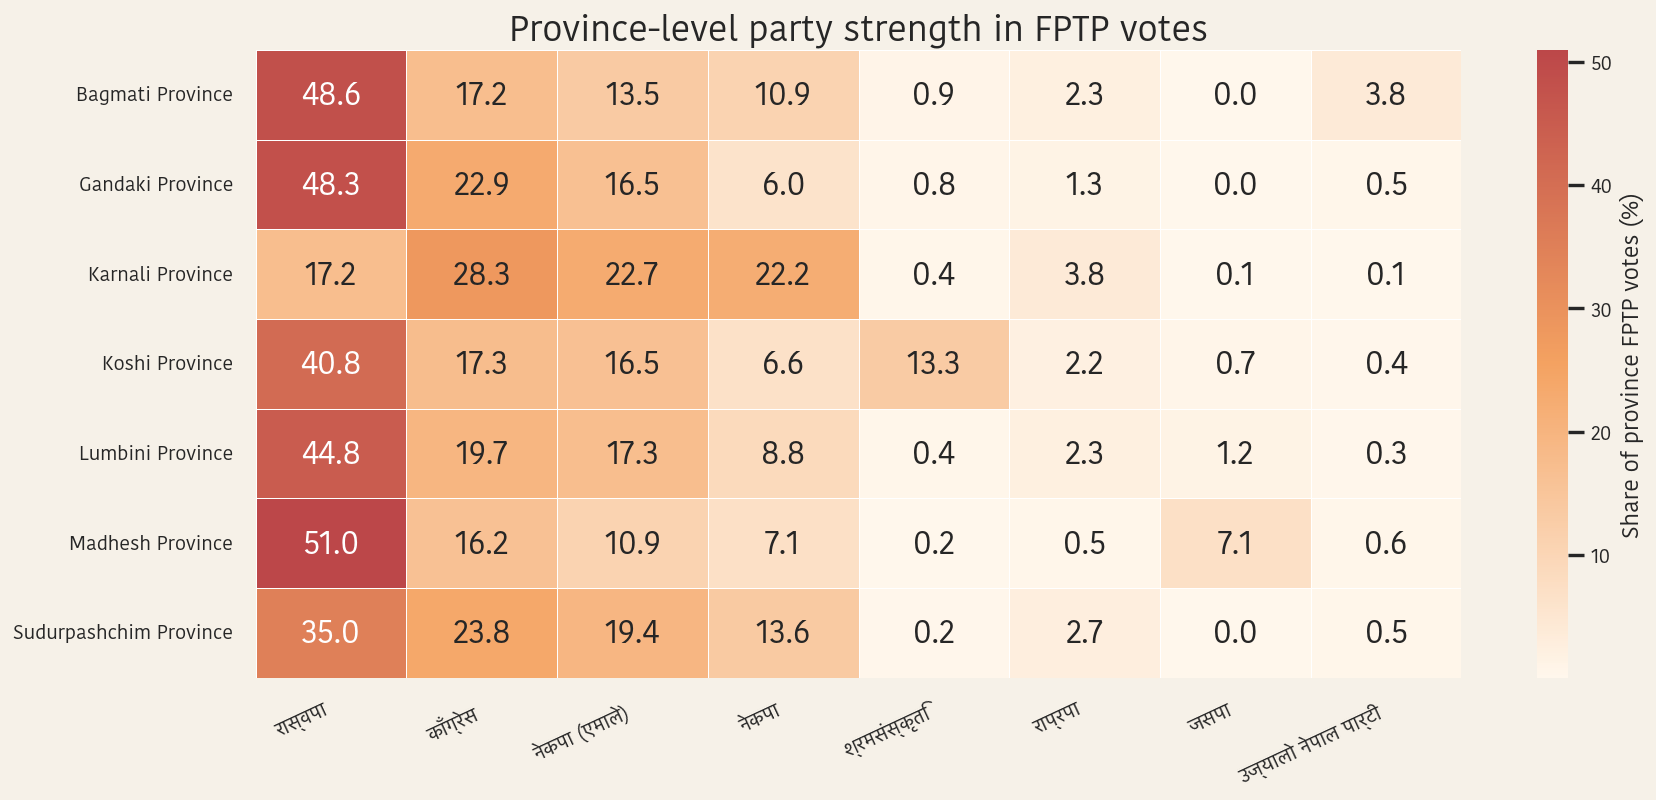

In [141]:
province_party_votes = (
    candidate_df.groupby(["state_name", "party_clean"], as_index=False)["votes"]
    .sum()
    .rename(columns={"party_clean": "party_name"})
)
province_totals = province_party_votes.groupby("state_name")["votes"].transform("sum")
province_party_votes["state_vote_share"] = province_party_votes["votes"] / province_totals * 100

province_focus_parties = fptp_party_votes.sort_values("fptp_votes", ascending=False).head(8)["party_name"].tolist()
heatmap_df = (
    province_party_votes[province_party_votes["party_name"].isin(province_focus_parties)]
    .pivot(index="state_name", columns="party_name", values="state_vote_share")
    .fillna(0)
)
heatmap_df = heatmap_df[province_focus_parties]
heatmap_df.columns = [axis_party_label(x) for x in heatmap_df.columns]

fig, ax = plt.subplots(figsize=(14, 6.5))
cmap = LinearSegmentedColormap.from_list("vote_heat", ["#fff7ec", "#f4a261", "#bc4749"])
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap=cmap,
    cbar_kws={"label": "Share of province FPTP votes (%)"},
    ax=ax,
)
ax.set_title("Province-level party strength in FPTP votes")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(list(heatmap_df.columns), rotation=25, ha="right")
plt.tight_layout()
export_figure(fig, "vote_type_province_heatmap.png")
plt.show()

This is a relative-strength map, not a raw-vote map. It shows which parties capture a larger share of a province’s constituency vote pool, making regional strongholds easier to spot.

## Parliament Seat Outlook (275 Seats)

The parliament outlook now applies the **3% proportional-vote threshold** before PR seats are distributed.

1. **FPTP seats (165):** taken directly from winner flags in the constituency results file.
2. **PR seats (110):** first identify parties with at least `3%` of total proportional votes, then allocate the 110 PR seats among only those eligible parties using the largest-remainder method.

Parties below the 3% threshold keep their recorded vote totals in the analysis but receive **zero projected PR seats** in the seat model. This makes the seat outlook closer to the intended rule while remaining fully derived from the attached files.

,Category,Value
0,PR threshold,"3% (325,051 votes)"
1,Eligible parties,6 parties
2,Excluded parties,51 parties
3,Votes retained for PR allocation,"9,926,713"


Exported Images/parliament_companion_charts.png


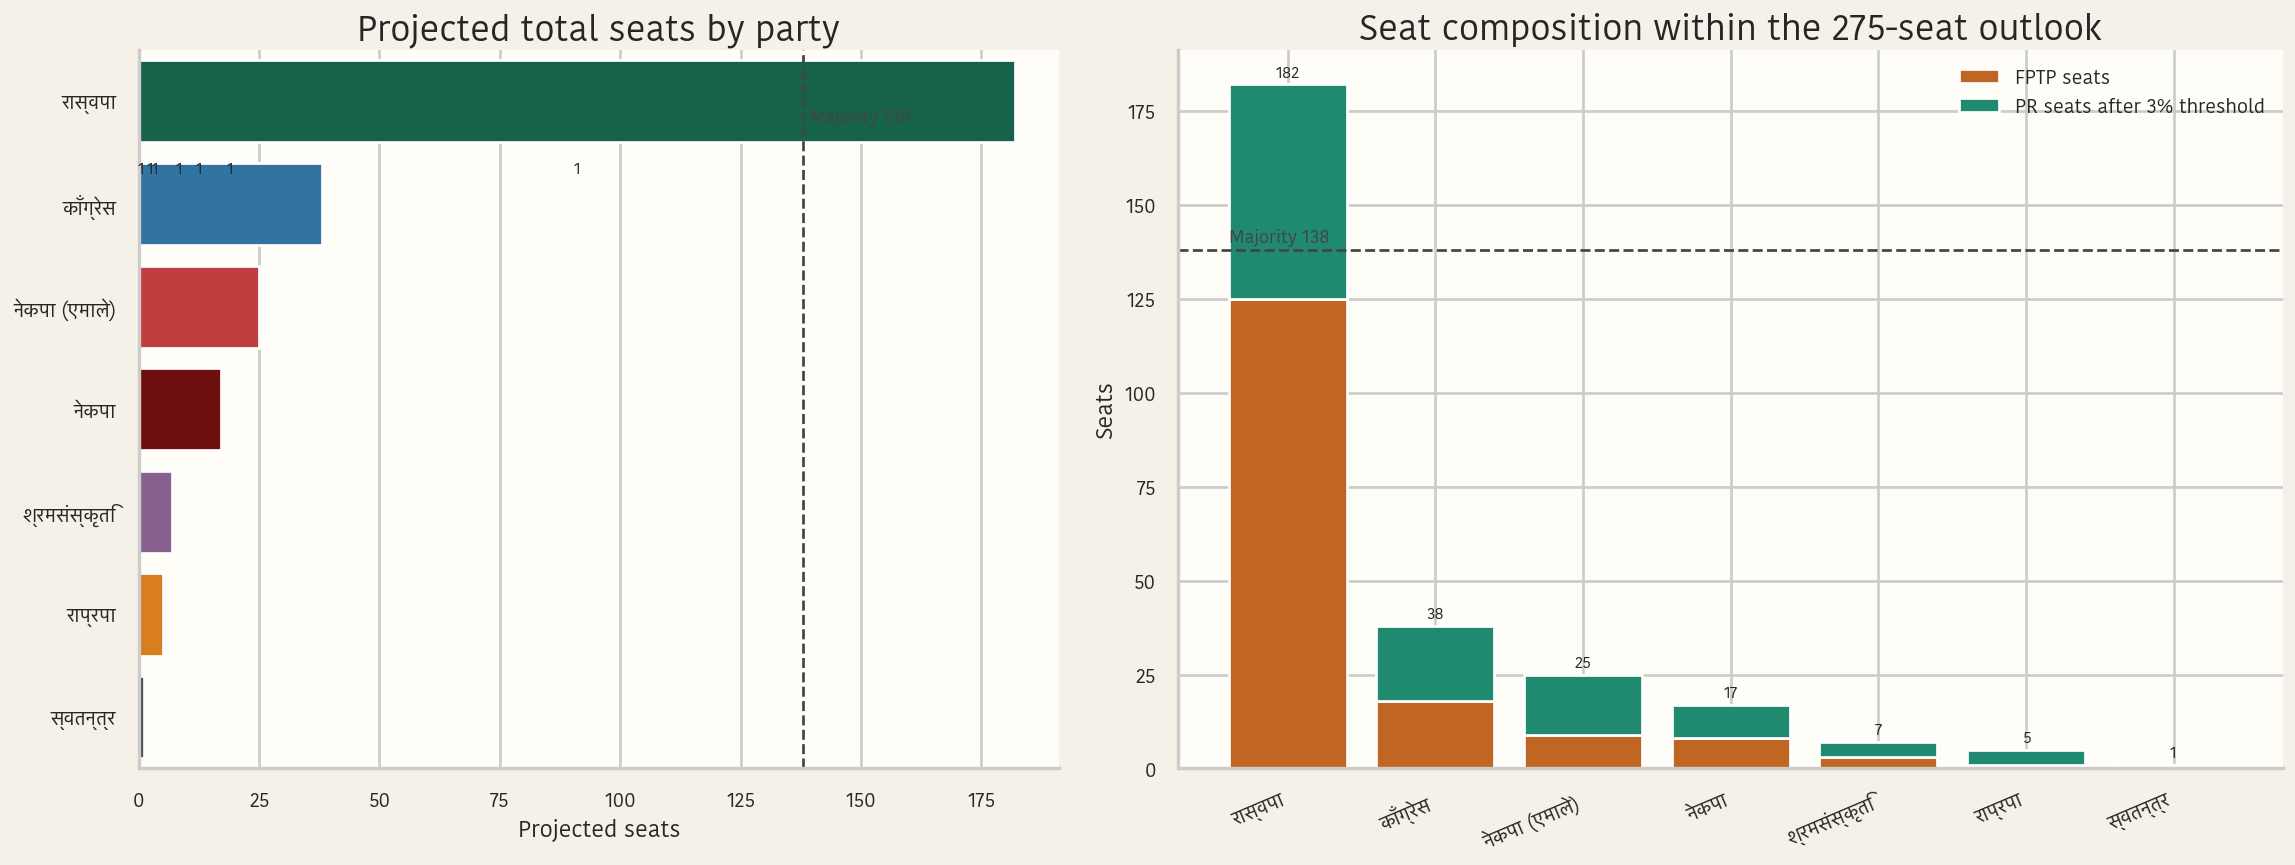

In [142]:
parliament_view = seat_outlook[seat_outlook["total_projected_seats"] > 0].sort_values("total_projected_seats", ascending=False).copy()
parliament_view["party_display"] = parliament_view["party_name"].map(axis_party_label)
pr_rule_summary = pd.DataFrame({
    "Category": ["PR threshold", "Eligible parties", "Excluded parties", "Votes retained for PR allocation"],
    "Value": [
        f"{PR_THRESHOLD:.0%} ({pr_threshold_votes:,.0f} votes)",
        f"{pr_eligible.shape[0]} parties",
        f"{pr_ineligible.shape[0]} parties",
        f"{pr_eligible['pr_votes'].sum():,}",
    ],
})
display(pr_rule_summary)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1, 1.2]})

sns.barplot(
    data=parliament_view.head(12),
    x="total_projected_seats",
    y="party_display",
    palette=[get_party_color(p) for p in parliament_view.head(12)["party_name"]],
    ax=axes[0],
)
axes[0].axvline(MAJORITY_THRESHOLD, color="#444444", linestyle="--", linewidth=1.5)
axes[0].text(MAJORITY_THRESHOLD + 1.5, 0.2, f"Majority {MAJORITY_THRESHOLD}", fontsize=10, color="#444444")
axes[0].set_title("Projected total seats by party")
axes[0].set_xlabel("Projected seats")
axes[0].set_ylabel("")
annotate_bars(axes[0], fmt="exact", fontsize=9)

seat_stack = parliament_view.head(12).copy()
axes[1].bar(seat_stack["party_display"], seat_stack["fptp_seats"], color="#c16622", label="FPTP seats")
axes[1].bar(
    seat_stack["party_display"],
    seat_stack["pr_projected_seats"],
    bottom=seat_stack["fptp_seats"],
    color="#1f8a70",
    label="PR seats after 3% threshold",
)
axes[1].axhline(MAJORITY_THRESHOLD, color="#444444", linestyle="--", linewidth=1.5)
axes[1].text(-0.4, MAJORITY_THRESHOLD + 2.0, f"Majority {MAJORITY_THRESHOLD}", fontsize=10, color="#444444")
axes[1].set_title("Seat composition within the 275-seat outlook")
axes[1].set_xlabel("")
axes[1].set_ylabel("Seats")
axes[1].set_xticks(range(len(seat_stack)))
axes[1].set_xticklabels(seat_stack["party_display"], rotation=23, ha="right")
for i, total in enumerate(seat_stack["total_projected_seats"]):
    axes[1].text(i, total + 1.2, f"{int(total)}", ha="center", va="bottom", fontsize=9)
axes[1].legend(frameon=False)

sns.despine()
plt.tight_layout()
export_figure(fig, "parliament_companion_charts.png")
plt.show()

Exported Images/parliament_seatmap.png


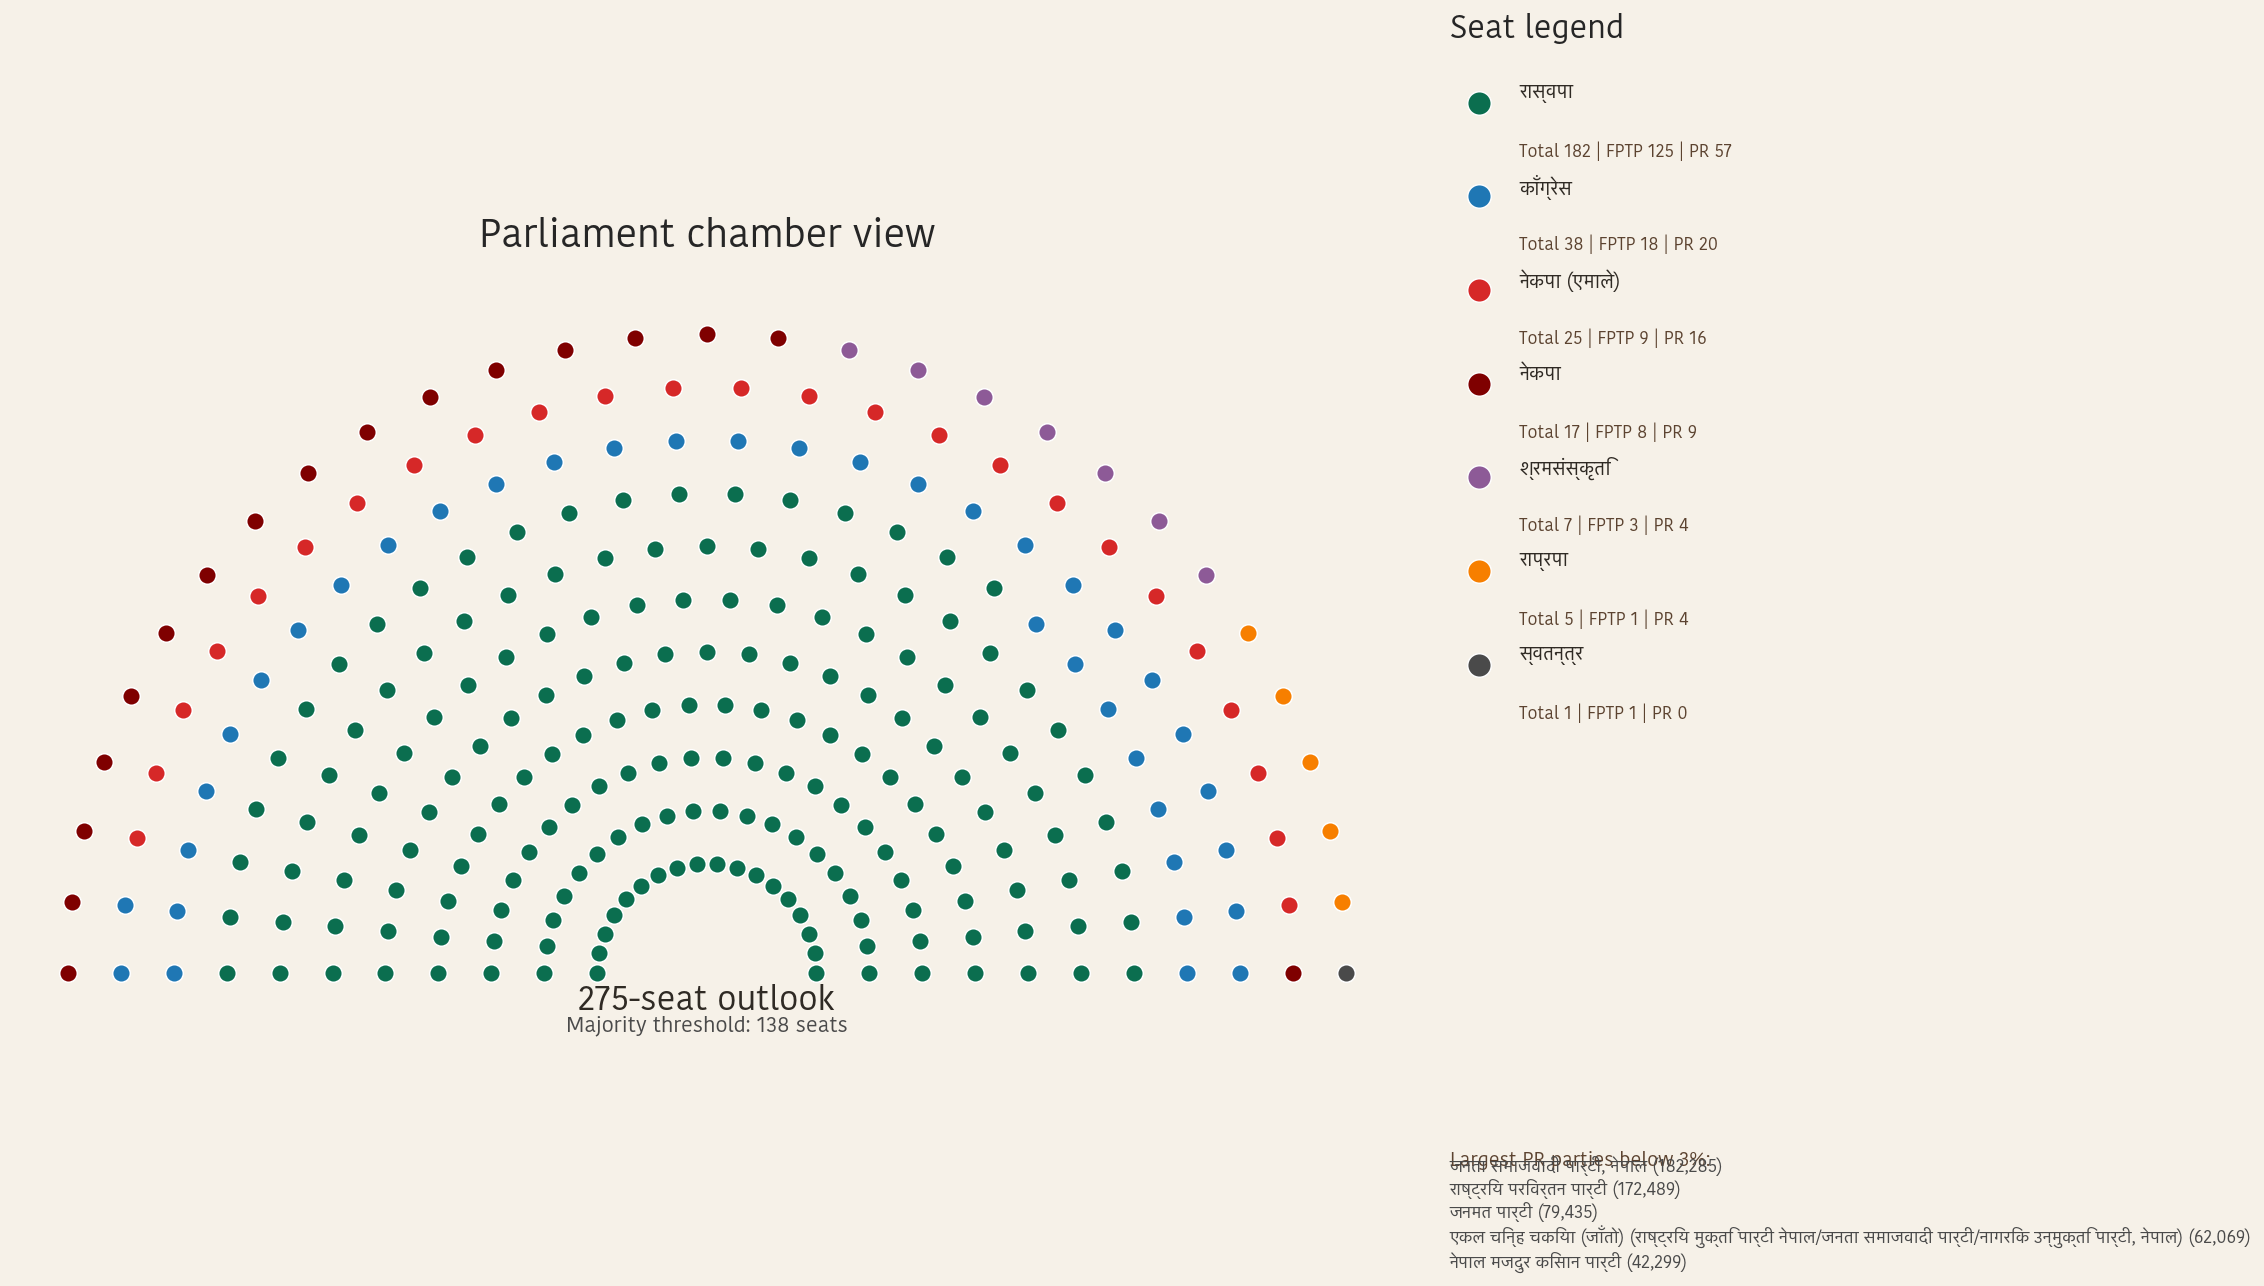

In [143]:
seat_positions = parliament_seat_positions()
seat_sequence = []
for _, row in parliament_view.iterrows():
    seat_sequence.extend([row["party_name"]] * int(row["total_projected_seats"]))
seat_sequence = seat_sequence[:TOTAL_PARLIAMENT_SEATS]

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[2.4, 1], wspace=0.05)
ax = fig.add_subplot(gs[0, 0])
legend_ax = fig.add_subplot(gs[0, 1])

for party in parliament_view["party_name"]:
    idx = [i for i, seat_party in enumerate(seat_sequence) if seat_party == party]
    if not idx:
        continue
    coords = seat_positions[idx]
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        s=95,
        color=get_party_color(party),
        edgecolor="white",
        linewidth=0.85,
        zorder=3,
    )

ax.text(0, -0.6, f"{TOTAL_PARLIAMENT_SEATS}-seat outlook", ha="center", va="center", fontsize=19, fontweight="bold", color="#2f2a24")
ax.text(0, -1.15, f"Majority threshold: {MAJORITY_THRESHOLD} seats", ha="center", va="center", fontsize=12, color="#4a4a4a")
ax.set_xlim(-15.2, 15.2)
ax.set_ylim(-1.8, 15.2)
ax.set_title("Parliament chamber view", fontsize=22, pad=18)
ax.axis("off")
ax.set_aspect("equal")

legend_ax.axis("off")
legend_ax.set_title("Seat legend", loc="left", fontsize=18, pad=16)
legend_items = parliament_view[["party_name", "fptp_seats", "pr_projected_seats", "total_projected_seats"]].copy()
legend_items["label"] = legend_items["party_name"].map(axis_party_label)

y = 0.97
for _, row in legend_items.iterrows():
    legend_ax.scatter(0.05, y, s=170, color=get_party_color(row["party_name"]), edgecolor="white", linewidth=0.8, transform=legend_ax.transAxes)
    legend_ax.text(0.12, y + 0.008, row["label"], transform=legend_ax.transAxes, fontsize=10.8, va="center", color="#2f2a24")
    legend_ax.text(
        0.12,
        y - 0.04,
        f"Total {int(row['total_projected_seats'])} | FPTP {int(row['fptp_seats'])} | PR {int(row['pr_projected_seats'])}",
        transform=legend_ax.transAxes,
        fontsize=9.8,
        va="center",
        color="#5c4330",
    )
    y -= 0.078
    if y < 0.12:
        break

excluded_note = (
    pr_ineligible.sort_values("pr_votes", ascending=False)[["party_name", "pr_votes"]]
    .head(5)
    .assign(text=lambda d: d["party_name"] + " (" + d["pr_votes"].map(lambda x: f"{x:,}") + ")")
)
legend_ax.text(0.0, 0.085, "Largest PR parties below 3%:", transform=legend_ax.transAxes, fontsize=11, fontweight="bold", color="#5c4330")
legend_ax.text(
    0.0,
    0.0,
    "\n".join(excluded_note["text"]) if not excluded_note.empty else "None",
    transform=legend_ax.transAxes,
    fontsize=9.8,
    color="#4a4a4a",
)

plt.tight_layout()
export_figure(fig, "parliament_seatmap.png")
plt.show()

The bar charts show totals and composition; the seatmap turns that into an intuitive chamber view. If one party reaches or crosses the marked 138-seat threshold, it would have a majority in this approximation.

## Key Facts and Highlights

This section condenses the analysis into notable headline facts, including the strongest performances, biggest system gaps, competitiveness extremes, and alignment coverage.

,Fact,Party / constituency,Value
0,Highest proportional vote total,राष्ट्रिय स्वतन्त्र पार्टी,"5,183,493"
1,Highest aggregated FPTP vote total,राष्ट्रिय स्वतन्त्र पार्टी,"4,650,500"
2,Most FPTP constituency wins,राष्ट्रिय स्वतन्त्र पार्टी,125
3,Closest constituency race,Okhaldhunga - Area 1,5
4,Biggest victory margin,Rupandehi - Area 3,"50,379"
5,Strongest FPTP-to-PR ratio*,स्वाभिमान पार्टी,1.40
6,Strongest PR-to-FPTP ratio*,राष्ट्रिय परिवर्तन पार्टी,17.24
7,Largest absolute vote gap,राष्ट्रिय स्वतन्त्र पार्टी,"532,993"
8,Best vote-to-seat efficiency,राष्ट्रिय स्वतन्त्र पार्टी,"54,032.93"
9,Matched parties / vote coverage,46 parties,0.99


Exported Images/key_facts_top_pr_votes.png


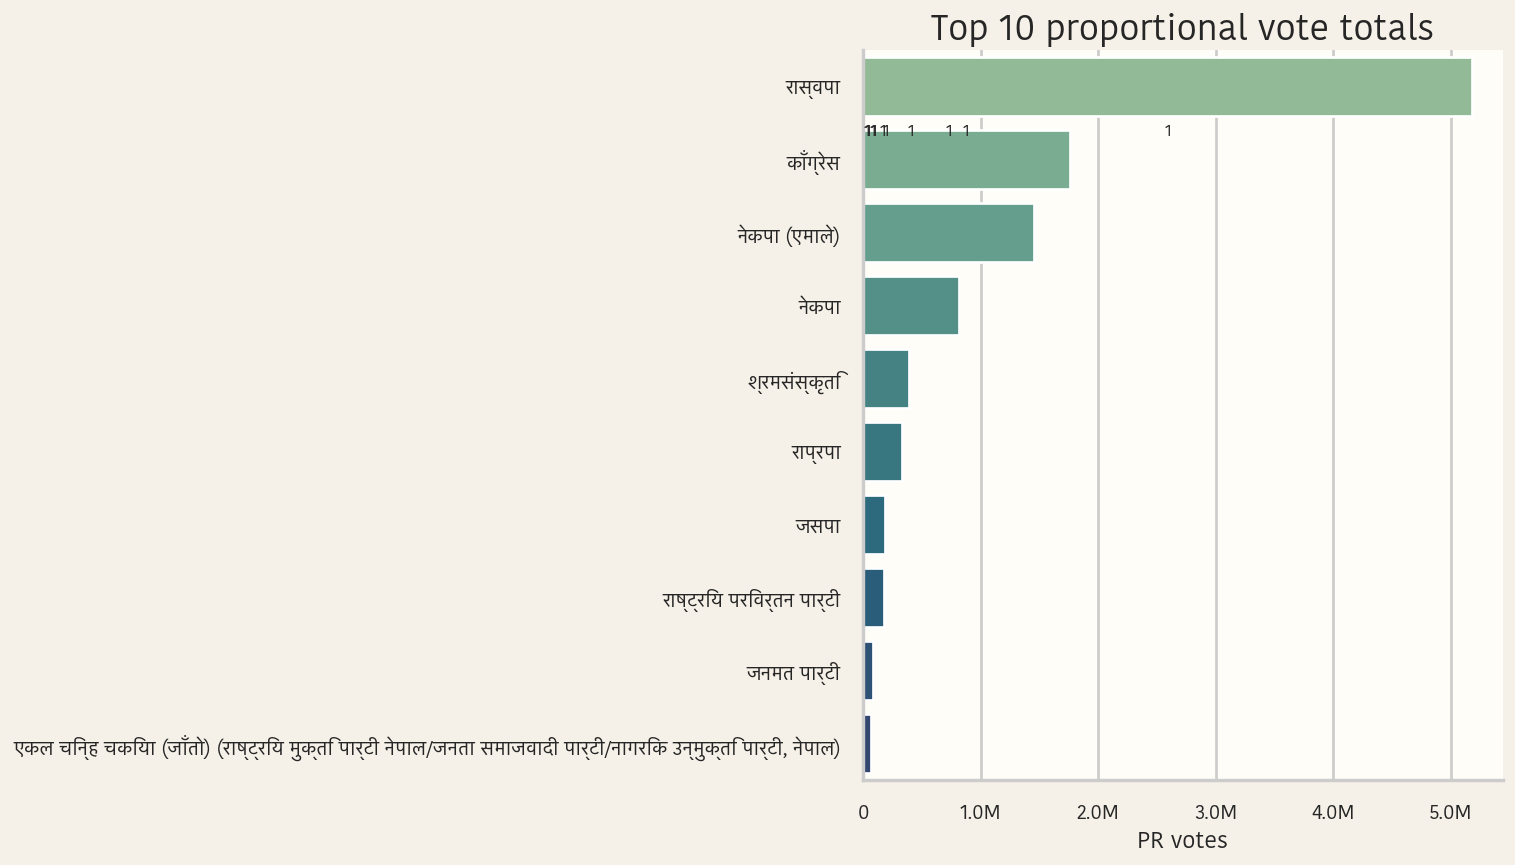

Exported Images/key_facts_top_fptp_votes.png


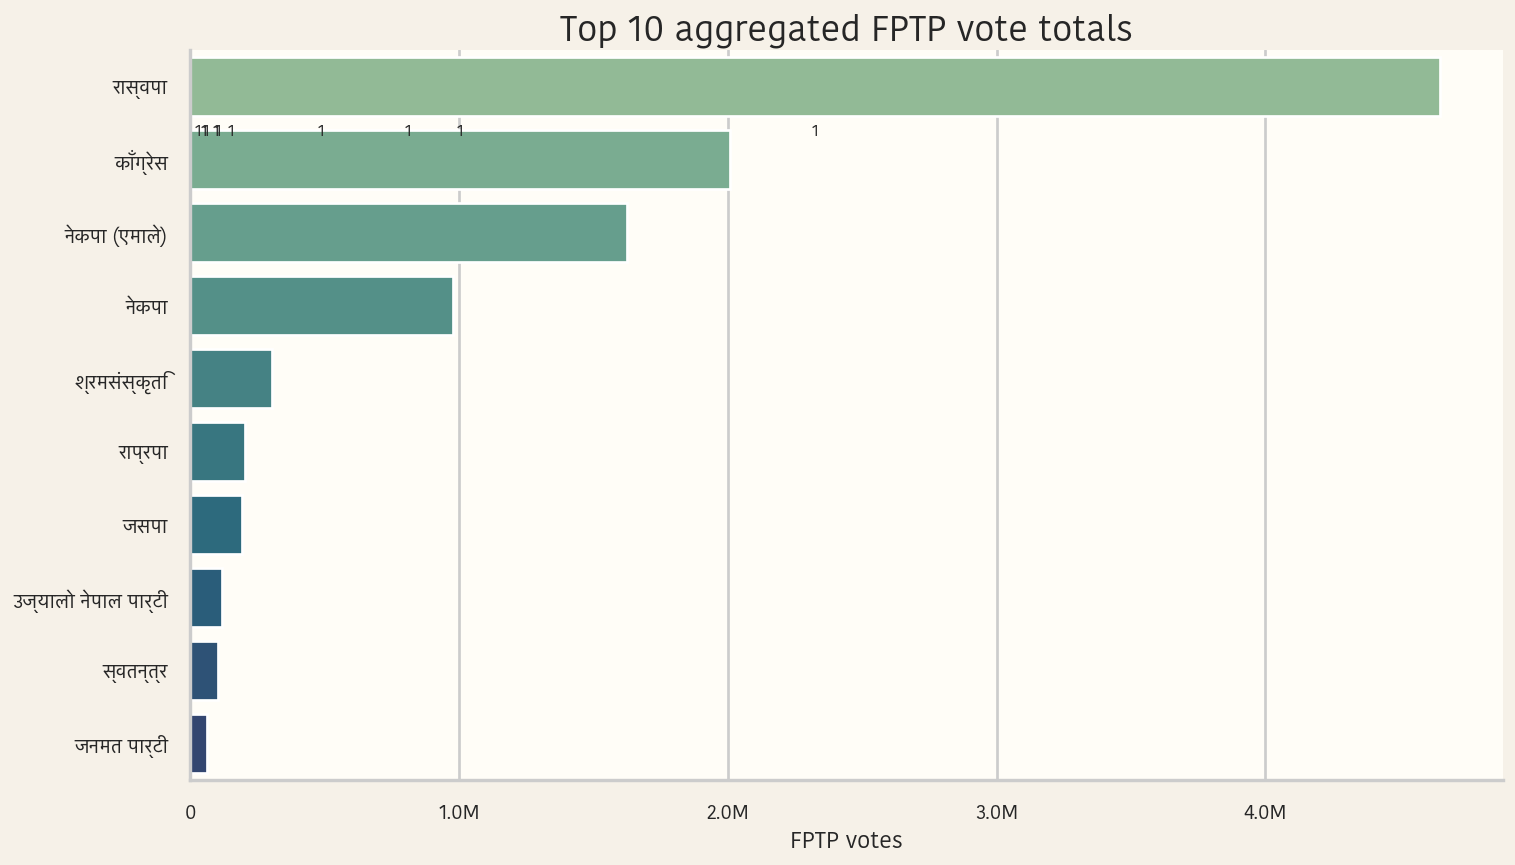

Exported Images/key_facts_top_closest_races.png


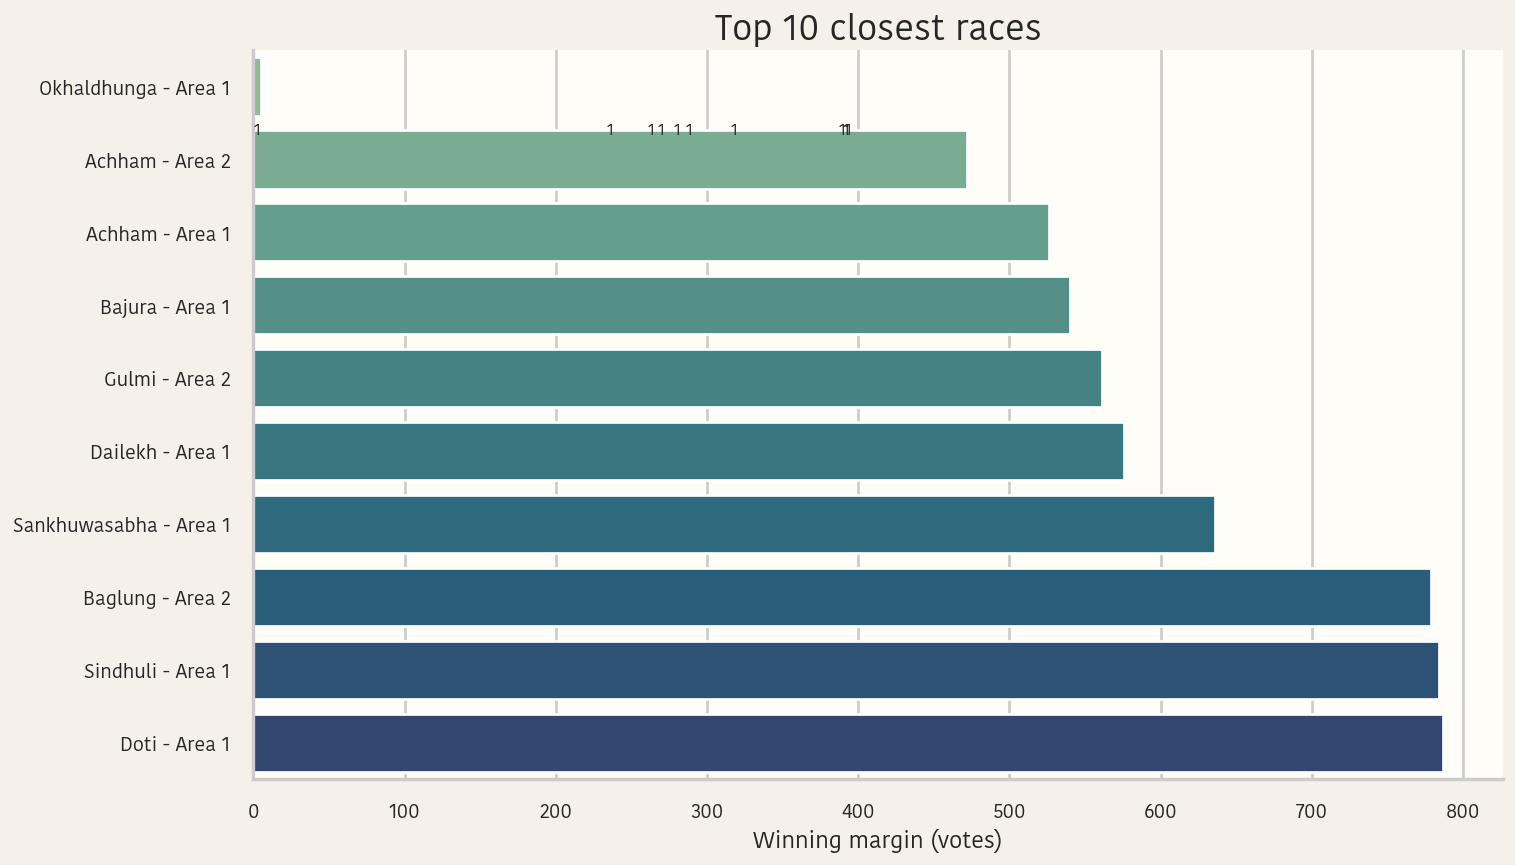

Exported Images/key_facts_top_victory_margins.png


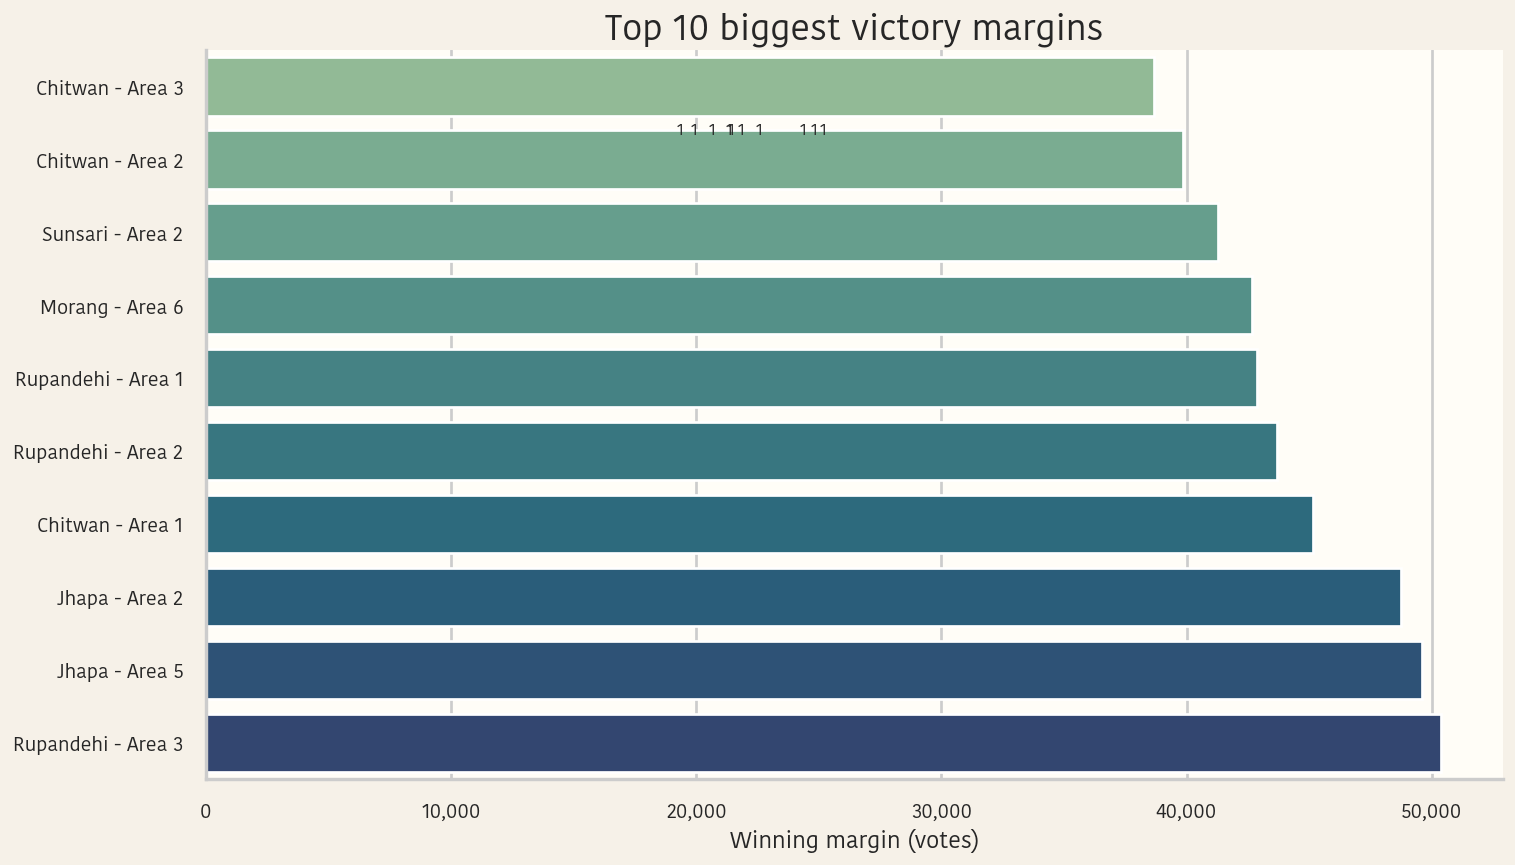

Exported Images/key_facts_top_vote_efficiency.png


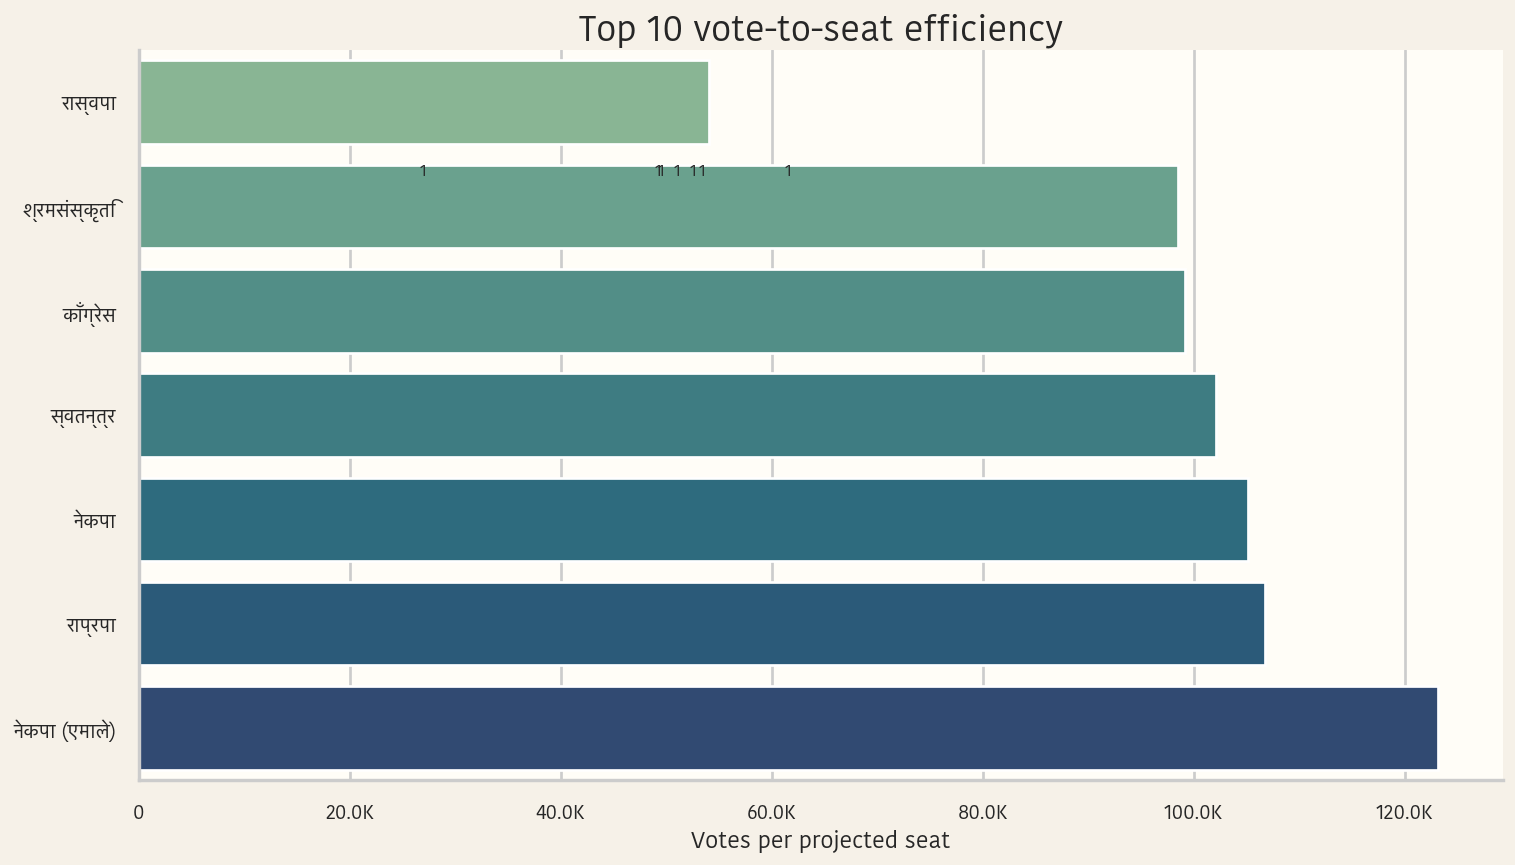

*Ratio facts use parties with at least 5,000 votes in both systems to avoid unstable extremes from tiny denominators.*

In [144]:
stable_ratio_view = matched[(matched["fptp_votes"] >= 5_000) & (matched["pr_votes"] >= 5_000)].copy()
closest_race = margins.nsmallest(1, "margin_votes").iloc[0]
landslide = margins.nlargest(1, "margin_votes").iloc[0]
best_efficiency = seat_outlook[seat_outlook["total_projected_seats"] > 0].nsmallest(1, "votes_per_total_seat").iloc[0]

facts_table = pd.DataFrame([
    {"Fact": "Highest proportional vote total", "Party / constituency": proportional_df.sort_values("total_votes", ascending=False).iloc[0]["party_clean"], "Value": int(proportional_df["total_votes"].max())},
    {"Fact": "Highest aggregated FPTP vote total", "Party / constituency": fptp_party_votes.sort_values("fptp_votes", ascending=False).iloc[0]["party_name"], "Value": int(fptp_party_votes["fptp_votes"].max())},
    {"Fact": "Most FPTP constituency wins", "Party / constituency": fptp_seats.sort_values("fptp_seats", ascending=False).iloc[0]["party_name"], "Value": int(fptp_seats["fptp_seats"].max())},
    {"Fact": "Closest constituency race", "Party / constituency": closest_race["constituency"], "Value": int(closest_race["margin_votes"])},
    {"Fact": "Biggest victory margin", "Party / constituency": landslide["constituency"], "Value": int(landslide["margin_votes"])},
    {"Fact": "Strongest FPTP-to-PR ratio*", "Party / constituency": stable_ratio_view.sort_values("fptp_to_pr_ratio", ascending=False).iloc[0]["party_name"], "Value": stable_ratio_view["fptp_to_pr_ratio"].max()},
    {"Fact": "Strongest PR-to-FPTP ratio*", "Party / constituency": stable_ratio_view.sort_values("pr_to_fptp_ratio", ascending=False).iloc[0]["party_name"], "Value": stable_ratio_view["pr_to_fptp_ratio"].max()},
    {"Fact": "Largest absolute vote gap", "Party / constituency": matched.sort_values("vote_abs_gap", ascending=False).iloc[0]["party_name"], "Value": int(matched["vote_abs_gap"].max())},
    {"Fact": "Best vote-to-seat efficiency", "Party / constituency": best_efficiency["party_name"], "Value": float(best_efficiency["votes_per_total_seat"])},
    {"Fact": "Matched parties / vote coverage", "Party / constituency": f"{matched.shape[0]} parties", "Value": float(matched['pr_votes'].sum() / pr_party_votes['pr_votes'].sum())},
])

display(facts_table.style.format({
    "Value": lambda x: f"{x:,.2f}" if isinstance(x, float) and not float(x).is_integer() else f"{int(round(x)):,}" if pd.notna(x) else "",
}))

fact_chart_specs = [
    (
        pr_party_votes.sort_values("pr_votes", ascending=False).head(10).copy(),
        "pr_votes",
        "Top 10 proportional vote totals",
        "PR votes",
        "key_facts_top_pr_votes.png",
    ),
    (
        fptp_party_votes.sort_values("fptp_votes", ascending=False).head(10).copy(),
        "fptp_votes",
        "Top 10 aggregated FPTP vote totals",
        "FPTP votes",
        "key_facts_top_fptp_votes.png",
    ),
    (
        margins.nsmallest(10, "margin_votes").sort_values("margin_votes", ascending=True)[["constituency", "margin_votes"]].copy(),
        "margin_votes",
        "Top 10 closest races",
        "Winning margin (votes)",
        "key_facts_top_closest_races.png",
    ),
    (
        margins.nlargest(10, "margin_votes").sort_values("margin_votes", ascending=True)[["constituency", "margin_votes"]].copy(),
        "margin_votes",
        "Top 10 biggest victory margins",
        "Winning margin (votes)",
        "key_facts_top_victory_margins.png",
    ),
    (
        seat_outlook[seat_outlook["total_projected_seats"] > 0].nsmallest(10, "votes_per_total_seat")[["party_name", "votes_per_total_seat"]].copy(),
        "votes_per_total_seat",
        "Top 10 vote-to-seat efficiency",
        "Votes per projected seat",
        "key_facts_top_vote_efficiency.png",
    ),
]

for df_plot, value_col, title, xlabel, filename in fact_chart_specs:
    label_col = "party_name" if "party_name" in df_plot.columns else "constituency"
    if label_col == "party_name":
        df_plot = df_plot.assign(display_label=df_plot["party_name"].map(axis_party_label))
        label_col = "display_label"

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(
        data=df_plot,
        x=value_col,
        y=label_col,
        palette=[get_party_color(p) for p in df_plot[label_col]] if label_col == "party_name" else sns.color_palette("crest", len(df_plot)),
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    if value_col == "votes_per_total_seat":
        ax.xaxis.set_major_formatter(approx_formatter())
        annotate_bars(ax, fmt="approx", fontsize=9)
    else:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}" if abs(x) < 1_000_000 else approx_number(x)))
        annotate_bars(ax, fmt="exact", fontsize=9)
    sns.despine()
    plt.tight_layout()
    export_figure(fig, filename)
    plt.show()

display(Markdown("*Ratio facts use parties with at least 5,000 votes in both systems to avoid unstable extremes from tiny denominators.*"))

## Final Findings

**Main takeaways**

- The top-tier party structure is broadly similar across FPTP and PR, but the size of each party’s support base shifts meaningfully between systems.
- The constituency file shows a highly concentrated FPTP winner pattern, while PR votes distribute support more widely across parties.
- The blended 275-seat outlook therefore changes the picture: FPTP winners keep a large advantage, but PR allocation partially broadens representation.
- Margin analysis confirms that some seats were decided narrowly, even while the overall seat table remains very uneven.
- Province-level patterns show that party strength is not uniformly national; several parties are materially stronger in specific regions.

This notebook is intended as a transparent analytical view built only from the attached files. Where the files do not encode the full legal PR process, the notebook labels the seat outlook as an approximation rather than implying exact constitutional allocation.